# QTS Project  
## Option Wheel Strategy

This project studies a systematic options wheel strategy implemented on listed American equity options. The framework integrates multi-factor stock selection with option premium harvesting under a margin-based capital structure.



---

**Course:** Quantitative Trading Strategy  
**Group:** Final Project Group PF: J 

**Group Members**

- **Name**: Mingshu Lu   **Student ID**: 12496646
- **Name**: Jackie Zhang   **Student ID**: 12498155
- **Name**: Theo Li          **Student ID**: 12503045
- **Name**: Jessica Xu       **Student ID**: 12503042
- **Name**: Catherine Chen   **Student ID**: 12496600

# Project Overview

This project studies a systematic options wheel strategy implemented on listed American-style equity options written on U.S. large-cap stocks. The framework combines equity selection and option premium harvesting within a unified backtesting structure. We'll use the data from 2016-04-29 to 2024-12-31. The objective is to evaluate whether disciplined short-volatility exposure, when applied to a selected set of liquid underlying equities, can generate attractive risk-adjusted returns over an extended sample period.

The strategy operates through monthly rolling option positions while maintaining a multi-year investment horizon to ensure exposure across different market regimes. Both assignment and premium collection dynamics are explicitly modeled, allowing the portfolio to alternate between cash-secured puts and covered calls. Capital allocation, transaction costs, and execution frictions are incorporated to ensure realistic performance estimation.

The backtest spans more than five years and includes at least five distinct underlying equities, generating sufficient trade frequency for statistical evaluation. Performance is assessed across full-sample and stressed market environments in order to evaluate robustness under varying volatility conditions.

# 0. Strategy Architecture

This session defines the structural architecture of the strategy and clarifies how the equity selection layer interacts with the options execution layer. The objective is to establish a clear mapping between conceptual design and the implementation that follows in code.

The strategy consists of two interacting components:

1. A semiannual equity selection mechanism
2. A monthly options wheel execution mechanism

The equity layer determines the eligible stock universe at each rebalance date, while the option layer generates recurring premium income conditional on that selected universe.

Rebalance frequencies are defined as:

$$
T_{equity} = 6 \text{ months}
$$

$$
T_{option} = 4 \text{ weeks}
$$

The code in subsequent sections will construct these two timing cycles explicitly and implement their interaction within a unified backtesting engine.

# 1. Equity Selection

This session constructs the equity selection mechanism that determines which underlying stocks are eligible for option writing. The objective is to formalize the stock ranking process and produce a time-indexed selected stock set.

The data sources are as follows:
- Daily stock market cap, fundamental, analyst consensus data from WRDS(CRSP/IBES)

The selection rule is based on a composite factor score defined as:

$$
Score_i = 0.5 MV_i + 0.2 Q_i + 0.2 M_i + 0.1 C_i
$$

where $MV_i$, $Q_i$, $M_i$, and $C_i$ denote standardized market capitalization, quality, momentum, and analyst consensus signals.

At each semiannual rebalance date, stocks are ranked cross-sectionally and the top-ranked securities are selected. The selected set is denoted as:

$$
\mathcal{S}_t = \{ i_1, i_2, ..., i_k \}
$$

The code in this session will compute factor signals, perform cross-sectional ranking, and construct the time-series of selected stock pools.

Note: Here, we use the data from 2015-10-01 in order to have 30-day rolling window to calculate sigma and further delta. After calculating delta, we will filter the data to start from 2016-04-29, which is the first rebalance date.

In [3]:
import pandas as pd
import numpy as np
import wrds

# ==========================================
# 1. Data Ingestion: WRDS Pipeline
# ==========================================
def build_sp500_universe_pipeline(username: str, start_date: str = '2011-01-01', end_date: str = '2024-12-31') -> pd.DataFrame:
    """
    Fetches CRSP pricing (including shares outstanding for Market Cap), 
    Compustat fundamentals, and IBES analyst consensus.
    """
    db = wrds.Connection(wrds_username=username)
    
    # print("Fetching CRSP daily prices and calculating Market Cap...")
    crsp_query = f"""
        SELECT a.date, b.ticker, a.prc, a.shrout
        FROM crsp.dsf AS a
        JOIN crsp.dsenames AS b ON a.permno = b.permno
        JOIN crsp.msp500list AS sp ON a.permno = sp.permno
        WHERE a.date >= '{start_date}' AND a.date <= '{end_date}'
        AND a.date >= sp.start AND (a.date <= sp.ending OR sp.ending IS NULL)
        AND a.date >= b.namedt AND a.date <= b.nameendt
    """
    df_price = db.raw_sql(crsp_query, date_cols=['date'])
    df_price['prc'] = df_price['prc'].abs()
    
    # Calculate Market Cap: Price * Shares Outstanding (shrout is usually in thousands)
    df_price['shrout'] = df_price['shrout'].fillna(0)
    df_price['market_cap'] = df_price['prc'] * df_price['shrout']
    
    # Calculate daily return and 6-month momentum
    df_price = df_price.sort_values(['ticker', 'date'])
    df_price['daily_return'] = df_price.groupby('ticker')['prc'].pct_change(1)
    df_price['mom6'] = df_price.groupby('ticker')['prc'].pct_change(126) 
    
    sp500_tickers = df_price['ticker'].dropna().unique().tolist()
    ticker_str = str(tuple(sp500_tickers)) if len(sp500_tickers) > 1 else f"('{sp500_tickers[0]}')"
        
    # print("Fetching Compustat fundamentals (Quality)...")
    comp_query = f"""
        SELECT datadate AS date, tic AS ticker, ni, seq
        FROM comp.funda
        WHERE tic IN {ticker_str}
        AND datadate >= '{start_date}' AND datadate <= '{end_date}'
        AND indfmt='INDL' AND datafmt='STD' AND popsrc='D' AND consol='C'
    """
    df_fund = db.raw_sql(comp_query, date_cols=['date'])
    df_fund['quality'] = df_fund['ni'] / df_fund['seq'].replace(0, np.nan)
    df_fund['quality'] = df_fund['quality'].astype(float)
    
    # print("Fetching IBES analyst consensus...")
    ibes_query = f"""
        SELECT statpers AS date, ticker, meanrec AS analyst_consensus
        FROM ibes.recdsum
        WHERE ticker IN {ticker_str}
        AND statpers >= '{start_date}' AND statpers <= '{end_date}'
    """
    df_ibes = db.raw_sql(ibes_query, date_cols=['date'])
    
    db.close()
    
    # print("Merging panel data...")
    df_price.set_index(['date', 'ticker'], inplace=True)
    df_fund.set_index(['date', 'ticker'], inplace=True)
    df_ibes.set_index(['date', 'ticker'], inplace=True)
    
    panel = df_price[['prc', 'daily_return', 'mom6', 'market_cap']].copy()
    panel = panel.join(df_fund[['quality']], how='left')
    panel = panel.join(df_ibes[['analyst_consensus']], how='left')
    
    panel['quality'] = panel.groupby(level='ticker')['quality'].ffill()
    panel['analyst_consensus'] = panel.groupby(level='ticker')['analyst_consensus'].ffill()
    
    panel = panel.reset_index()
    panel = panel[(panel['date'] >= '2015-10-01')]
    
    return panel.dropna()


# ==========================================
# 2. Rebalance Schedule (Semiannual)
# ==========================================
def generate_semiannual_rebalance_dates(panel: pd.DataFrame, start_date: str = '2013-04-01', end_date: str = '2024-12-31') -> list:
    """
    Generates semiannual (every 6 months) rebalance dates.
    Each rebalance date is the last trading day of the last full week of the target month.

    "Last full week" = the 7-calendar-day window ending on the last day of the month.
    Among all trading days in that window, pick the one with the highest dayofweek
    (Friday=4 preferred; falls back to Thursday, etc. if Friday is a holiday).

    This guarantees the rebalance date is always a week's last trading day,
    which is critical for downstream option roll alignment.
    """
    trading_dates = pd.to_datetime(pd.Series(panel['date'].unique()).sort_values()).reset_index(drop=True)
    trading_dates = trading_dates[(trading_dates >= start_date) & (trading_dates <= end_date)]

    df_td = pd.DataFrame({'date': trading_dates})
    df_td['year'] = df_td['date'].dt.year
    df_td['month'] = df_td['date'].dt.month
    df_td['day'] = df_td['date'].dt.day
    df_td['dayofweek'] = df_td['date'].dt.dayofweek  # Mon=0 ... Fri=4

    # Target months: every 6 months starting from start_date (e.g., Apr & Oct)
    target_months = pd.date_range(start=start_date, end=end_date, freq=pd.DateOffset(months=6))

    rebalance_dates = []
    for target in target_months:
        ty, tm = target.year, target.month
        grp = df_td[(df_td['year'] == ty) & (df_td['month'] == tm)]
        if grp.empty:
            continue

        # Last trading day of this month determines the "last full week" window
        last_td = grp['date'].max()
        last_day_of_month = last_td.day

        # Last full week: 7-day window ending on the last calendar day
        week_start_day = max(last_day_of_month - 6, 1)
        candidates = grp[grp['day'] >= week_start_day]

        # Pick the candidate with the highest dayofweek (closest to Friday)
        best = candidates.sort_values('dayofweek', ascending=False).iloc[0]
        rebalance_dates.append(best['date'].strftime('%Y-%m-%d'))

    rebalance_dates.sort()
    return rebalance_dates

# ==========================================
# 3. Factor Scoring & Selection
# ==========================================
def generate_universe_table(panel: pd.DataFrame, rebalance_dates: list) -> pd.DataFrame:
    """
    Applies the new 4-factor formula: Score = 0.5*MV + 0.2*Q + 0.2*M + 0.1*C
    """
    # print("Calculating composite scores and ranking equities...")
    rebal_df = panel[panel['date'].isin(pd.to_datetime(rebalance_dates))].copy()
    rebal_df.rename(columns={'date': 'rebalance_date'}, inplace=True)
    
    factors = ['market_cap', 'quality', 'mom6', 'analyst_consensus']
    
    # Step 1: Cross-sectional Z-score standardization
    for factor in factors:
        rebal_df[f'{factor}_z'] = rebal_df.groupby('rebalance_date')[factor].transform(
            lambda x: (x - x.mean()) / x.std() if x.std() != 0 else 0
        )
        
    # Step 2: Apply the weighted formula
    # NOTE: analyst_consensus is subtracted because a lower IBES score (1) means 'Strong Buy'
    rebal_df['composite_score'] = (
        0.5 * rebal_df['market_cap_z'] + 
        0.2 * rebal_df['quality_z'] + 
        0.2 * rebal_df['mom6_z'] - 
        0.1 * rebal_df['analyst_consensus_z']
    )
    
    # Step 3: Rank and Select Top 20
    rebal_df = rebal_df[rebal_df['prc'] <= 1000.0].copy()
    rebal_df['rank'] = rebal_df.groupby('rebalance_date')['composite_score'].rank(method='first', ascending=False)
    rebal_df['selected_flag'] = (rebal_df['rank'] <= 20).astype(int)
    rebal_df['weight'] = np.where(rebal_df['selected_flag'] == 1, 0.05, 0.0)
    
    # output_cols = ['rebalance_date', 'ticker', 'market_cap', 'quality', 'mom6', 'analyst_consensus', 
    #                'composite_score', 'rank', 'selected_flag', 'weight']
    
    output_cols = ['rebalance_date', 'ticker','rank', 'selected_flag']

    final_universe = rebal_df[output_cols].sort_values(['rebalance_date', 'rank'])
    final_universe = final_universe[final_universe['selected_flag'] == 1].reset_index(drop=True)
    
    return final_universe

if __name__ == "__main__":
    YOUR_USERNAME = 'harrisonl'
    
    # Run pipelines
    final_panel = build_sp500_universe_pipeline(username=YOUR_USERNAME)
    semi_annual_dates = generate_semiannual_rebalance_dates(final_panel)  # 半年调仓

    universe_table = generate_universe_table(panel=final_panel, rebalance_dates=semi_annual_dates)


Loading library list...
Done


C:\Users\Alienware\AppData\Local\Temp\ipykernel_42044\2280980877.py:34: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_price['daily_return'] = df_price.groupby('ticker')['prc'].pct_change(1)
C:\Users\Alienware\AppData\Local\Temp\ipykernel_42044\2280980877.py:35: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_price['mom6'] = df_price.groupby('ticker')['prc'].pct_change(126)


# 2. Data Loading, Cleaning, and Engineering Pipeline

This section defines the data infrastructure and preprocessing pipeline used to construct the research dataset. The objective is to transform raw equity and option data into a clean, aligned panel suitable for signal construction and backtesting.

The data sources are as follows:

- Daily listed option data from Databento API
- Daily stock price, fundamental, analyst consensus data from WRDS / IBES

All datasets are aligned to a common trading calendar and indexed by date and underlying ticker.

---

## 2.1 Equity Data Loading and Cleaning

This subsection loads daily equity price data from WRDS for the selected stocks.
The output of this step is a cleaned equity panel indexed by date and ticker, which serves as the foundation for factor ranking and portfolio construction.

In [4]:
universe_table[universe_table['rebalance_date']>="2016-04-29"].head()

,rebalance_date,ticker,rank,selected_flag
20,2016-04-29,AAPL,1.0,1
21,2016-04-29,MSFT,2.0,1
22,2016-04-29,AMZN,3.0,1
23,2016-04-29,JNJ,4.0,1
24,2016-04-29,GE,5.0,1


In [5]:
def fetch_underlying_price_by_universe(
    username: str,
    universe_table: pd.DataFrame,
    semi_annual_dates: list,
    end_date: str = '2024-12-31'
) -> pd.DataFrame:
    """
    For each (rebalance_date, ticker) in universe_table, fetch unadjusted daily close
    from CRSP dsf for the period [rebalance_date, next_rebalance_date].
    The last rebalance window extends to `end_date`.

    Returns: DataFrame with columns [date, ticker, close, rebalance_date]
    """
    # Build rebalance windows: each ticker is held from its rebalance_date to the next one
    dates_sorted = sorted(pd.to_datetime(semi_annual_dates))
    # Map each rebalance_date to the next rebalance_date (or end_date for the last one)
    next_date_map = {}
    for i, d in enumerate(dates_sorted):
        if i + 1 < len(dates_sorted):
            next_date_map[d] = dates_sorted[i + 1]
        else:
            next_date_map[d] = pd.Timestamp(end_date)

    universe_table = universe_table.copy()
    universe_table['rebalance_date'] = pd.to_datetime(universe_table['rebalance_date'])
    universe_table['next_rebalance_date'] = universe_table['rebalance_date'].map(next_date_map)

    # Get all unique tickers and the full date range needed
    all_tickers = universe_table['ticker'].unique().tolist()
    global_start = universe_table['rebalance_date'].min().strftime('%Y-%m-%d')
    global_end = end_date

    ticker_str = str(tuple(all_tickers)) if len(all_tickers) > 1 else f"('{all_tickers[0]}')"

    # Single WRDS query: fetch all needed tickers over the full date range
    db = wrds.Connection(wrds_username=username)

    query = f"""
        SELECT a.date, b.ticker, ABS(a.prc) AS close, b.nameendt
        FROM crsp.dsf AS a
        JOIN crsp.dsenames AS b
          ON a.permno = b.permno
        WHERE b.ticker IN {ticker_str}
          AND a.date >= '{global_start}' AND a.date <= '{global_end}'
          AND a.date >= b.namedt AND a.date <= b.nameendt
        ORDER BY a.date, b.ticker, b.nameendt
    """
    price_df = db.raw_sql(query, date_cols=['date'])
    db.close()

    # Deduplicate: if a ticker maps to multiple permno on the same day, keep the latest nameendt
    price_df = (
        price_df.sort_values(['date', 'ticker', 'nameendt'])
        .drop_duplicates(['date', 'ticker'], keep='last')
        [['date', 'ticker', 'close']]
        .reset_index(drop=True)
    )

    # Filter: keep only rows within each ticker's valid rebalance window
    # Build a lookup of (ticker -> list of [rebalance_date, next_rebalance_date])
    windows = universe_table[['ticker', 'rebalance_date', 'next_rebalance_date']].drop_duplicates()

    # Merge price with windows on ticker, then filter by date range
    result = price_df.merge(windows, on='ticker', how='inner')
    result = result[
        (result['date'] >= result['rebalance_date']) &
        (result['date'] <= result['next_rebalance_date'])
    ]

    result = (
        result[['date', 'ticker', 'close', 'rebalance_date']]
        .sort_values(['rebalance_date', 'ticker', 'date'])
        .reset_index(drop=True)
    )

    return result


# ==========================================
# Run it
# ==========================================
if __name__ == "__main__":
    underlying_price = fetch_underlying_price_by_universe(
        username="harrisonl",
        universe_table=universe_table,
        semi_annual_dates=semi_annual_dates,
        end_date='2024-12-31'
    )

    print(f"UnderlyingPrice shape: {underlying_price.shape}")
    print(underlying_price.head(10))

Loading library list...
Done
UnderlyingPrice shape: (46500, 4)
        date ticker   close rebalance_date
0 2015-10-30   AAPL   119.5     2015-10-30
1 2015-11-02   AAPL  121.18     2015-10-30
2 2015-11-03   AAPL  122.57     2015-10-30
3 2015-11-04   AAPL   122.0     2015-10-30
4 2015-11-05   AAPL  120.92     2015-10-30
5 2015-11-06   AAPL  121.06     2015-10-30
6 2015-11-09   AAPL  120.57     2015-10-30
7 2015-11-10   AAPL  116.77     2015-10-30
8 2015-11-11   AAPL  116.11     2015-10-30
9 2015-11-12   AAPL  115.72     2015-10-30




---

## 2.2 Option Data Loading and Cleaning

This subsection loads daily option data from Databento API. The raw dataset includes option price, strike, expiration date, implied volatility, option delta, and open interest.

Contracts are filtered to approximately 4-week maturity in order to match the monthly rolling design of the wheel strategy. Illiquid contracts are removed based on open interest thresholds. Option records are merged with underlying equity prices to ensure pricing consistency.

The output is an aligned option panel indexed by date, underlying ticker, and contract characteristics.



Note: To save time, we split the option data fetching into five parts and run by different teammates. So we don't show the output of the fetching process here. The final assembled tables are concatenated by five parts in the next cell.

In [ ]:
import databento as db
import pandas as pd
import numpy as np
import time
from pathlib import Path
from calendar import monthrange



# ============================================================
# Configuration
# ============================================================
DATABENTO_API_KEY = "db-3ChhBApFsid58SHdLtCbgnDHcmnc4"  # Replace with your key
client = db.Historical(DATABENTO_API_KEY)


SHARD_START, SHARD_END, SHARD_TAG = "2023-09-29", "2023-11-30", "fix_3"


# Pre-existing tables expected in memory:
#   universe_table:    columns = ['rebalance_date', 'ticker', 'rank', 'selected_flag']
#   underlying_price:  columns = ['date', 'ticker', 'close', 'rebalance_date']
#   semi_annual_dates: list of semiannual rebalance date strings


# ============================================================
# Step 1: Generate MONTHLY option roll dates
#   Rule: last trading day of the last full week of each month
#   "Last full week" = 7-calendar-day window ending on the last day of the month
#   Among trading days in that window, pick the one with the highest dayofweek (prefer Friday)
# ============================================================

def generate_monthly_roll_dates(
    underlying_price: pd.DataFrame,
    start_date: str = SHARD_START,
    end_date: str = SHARD_END,
) -> list:
    """
    Generate monthly option roll dates using the same 'last full week' logic
    as the semiannual equity rebalance, but applied to EVERY month.
    """
    trading_dates = pd.to_datetime(
        underlying_price["date"].drop_duplicates().sort_values()
    ).reset_index(drop=True)
    trading_dates = trading_dates[
        (trading_dates >= start_date) & (trading_dates <= end_date)
    ]

    df_td = pd.DataFrame({"date": trading_dates})
    df_td["year"] = df_td["date"].dt.year
    df_td["month"] = df_td["date"].dt.month
    df_td["day"] = df_td["date"].dt.day
    df_td["dayofweek"] = df_td["date"].dt.dayofweek  # Mon=0 ... Fri=4

    # Generate target months: every single month from start to end
    target_months = pd.date_range(start=start_date, end=end_date, freq="MS")

    roll_dates = []
    for target in target_months:
        ty, tm = target.year, target.month
        grp = df_td[(df_td["year"] == ty) & (df_td["month"] == tm)]
        if grp.empty:
            continue

        last_td = grp["date"].max()
        last_day_of_month = last_td.day

        # Last full week: 7-day window ending on last calendar day
        week_start_day = max(last_day_of_month - 6, 1)
        candidates = grp[grp["day"] >= week_start_day]

        # Pick the candidate with the highest dayofweek (closest to Friday)
        best = candidates.sort_values("dayofweek", ascending=False).iloc[0]
        roll_dates.append(best["date"].strftime("%Y-%m-%d"))

    roll_dates.sort()
    return roll_dates


monthly_roll_dates = generate_monthly_roll_dates(underlying_price)
print(f"Generated {len(monthly_roll_dates)} monthly option roll dates")
print(f"First: {monthly_roll_dates[0]}, Last: {monthly_roll_dates[-1]}")
print(f"Sample: {monthly_roll_dates[:6]}")


# ============================================================
# Step 2: Build roll-date pairs (roll_date -> next_roll_date)
# ============================================================
roll_dates_ts = sorted(pd.to_datetime(monthly_roll_dates))
roll_dates_ts = [d for d in roll_dates_ts
                 if pd.Timestamp(SHARD_START) <= d <= pd.Timestamp(SHARD_END)]

next_roll_map = {}
for i, d in enumerate(roll_dates_ts):
    if i + 1 < len(roll_dates_ts):
        next_roll_map[d] = roll_dates_ts[i + 1]
    else:
        next_roll_map[d] = pd.Timestamp(SHARD_END)


# ============================================================
# Step 3: Map each monthly roll date to its active equity universe
#   Active universe = most recent semiannual rebalance on or before the roll date
# ============================================================
semi_dates_ts = sorted(pd.to_datetime(semi_annual_dates))

ut = universe_table[universe_table["selected_flag"] == 1].copy()
ut["rebalance_date"] = pd.to_datetime(ut["rebalance_date"])

def get_active_universe(roll_date: pd.Timestamp) -> pd.DataFrame:
    """Return the ticker list from the most recent semiannual rebalance <= roll_date."""
    eligible = [d for d in semi_dates_ts if d <= roll_date]
    if not eligible:
        return pd.DataFrame(columns=ut.columns)
    active_rebal = max(eligible)
    return ut[ut["rebalance_date"] == active_rebal]


# ============================================================
# Step 4: Build spot price lookup for roll dates
# ============================================================
up = underlying_price.copy()
up["date"] = pd.to_datetime(up["date"])

def get_spot_close(ticker: str, roll_date: pd.Timestamp) -> float:
    """Get closing price on or closest before roll_date."""
    subset = up[(up["ticker"] == ticker) & (up["date"] <= roll_date)]
    if subset.empty:
        return np.nan
    return subset.sort_values("date").iloc[-1]["close"]


# ============================================================
# Step 5: Fetch helper (same as before)
# ============================================================

def fetch_option_chain_for_ticker(
    client,
    ticker: str,
    roll_date: str,
    underlying_close: float,
    next_roll_date: str,
):
    """
    For a single ticker on a given roll_date:
    1. Pull 'definition' -> filter to options expiring around next_roll_date (DTE [21,27])
    2. Select 10 nearest OTM calls + 10 nearest OTM puts
    3. Pull 'OHLCV-1d' for those 20 contracts from roll_date to next_roll_date

    Returns (rebal_df, mtm_df) or (None, None) on failure.
    """
    opra_symbol = f"{ticker}.OPT"

    # --- Pull definition ---
    try:
        data_def = client.timeseries.get_range(
            dataset="OPRA.PILLAR",
            schema="definition",
            stype_in="parent",
            symbols=[opra_symbol],
            start=roll_date,
        )
        df_def = data_def.to_df()
    except Exception as e:
        print(f"    [WARN] definition pull failed {ticker} @ {roll_date}: {e}")
        return None, None

    if df_def.empty:
        return None, None

    df_def = df_def[["instrument_id", "strike_price", "expiration", "instrument_class", "symbol"]].copy()

    # Filter to DTE [21, 27] relative to roll_date
    current_ts = pd.Timestamp(roll_date, tz="UTC")

    df_filtered = df_def.loc[
        (df_def["expiration"] >= current_ts + pd.Timedelta(days=21)) &
        (df_def["expiration"] <= current_ts + pd.Timedelta(days=27))
    ].copy()

    if df_filtered.empty:
        # Widen to [14, 35] as fallback
        df_filtered = df_def.loc[
            (df_def["expiration"] >= current_ts + pd.Timedelta(days=14)) &
            (df_def["expiration"] <= current_ts + pd.Timedelta(days=35))
        ].copy()

    if df_filtered.empty:
        return None, None

    # Select 10 nearest OTM calls + 10 nearest OTM puts
    df_filtered["distance"] = (df_filtered["strike_price"] - underlying_close).abs()

    call_10 = (
        df_filtered[
            (df_filtered["instrument_class"] == "C") &
            (df_filtered["strike_price"] >= underlying_close)
        ]
        .sort_values(by=["distance", "strike_price"])
        .head(10)
    )

    put_10 = (
        df_filtered[
            (df_filtered["instrument_class"] == "P") &
            (df_filtered["strike_price"] <= underlying_close)
        ]
        .sort_values(by=["distance", "strike_price"], ascending=[True, False])
        .head(10)
    )

    selected_20 = pd.concat([call_10, put_10], ignore_index=False)
    if selected_20.empty:
        return None, None

    # Build rebal_df
    rebal_rows = []
    for _, row in selected_20.iterrows():
        dte_i = (row["expiration"] - current_ts).days
        rebal_rows.append({
            "date": pd.Timestamp(roll_date),
            "ticker": ticker,
            "cp_flag": row["instrument_class"],
            "exp_date": row["expiration"],
            "strike": row["strike_price"],
            "mid": np.nan,
            "dte": dte_i,
            "symbol": row["symbol"],
            "instrument_id": row["instrument_id"],
        })
    rebal_df = pd.DataFrame(rebal_rows)

    # Pull OHLCV-1d
    ids = selected_20["symbol"].tolist()
    try:
        data_ohlcv = client.timeseries.get_range(
            dataset="OPRA.PILLAR",
            schema="OHLCV-1d",
            symbols=ids,
            start=roll_date,
            end=next_roll_date,
        )
        df_ohlcv = data_ohlcv.to_df()
    except Exception as e:
        print(f"    [WARN] OHLCV pull failed {ticker} @ {roll_date}: {e}")
        return rebal_df, None

    if df_ohlcv.empty:
        return rebal_df, None

    df_ohlcv = df_ohlcv.reset_index()
    if "ts_event" in df_ohlcv.columns:
        df_ohlcv["date"] = pd.to_datetime(df_ohlcv["ts_event"], utc=True).dt.tz_convert(None).dt.normalize()

    contract_info = selected_20[["instrument_id", "strike_price", "expiration", "instrument_class"]].copy()
    df_ohlcv = df_ohlcv.merge(contract_info, on="instrument_id", how="inner")

    mtm_df = df_ohlcv[["date", "instrument_id", "strike_price", "expiration", "instrument_class", "close"]].copy()
    mtm_df = mtm_df.rename(columns={
        "close": "mid", "strike_price": "strike",
        "expiration": "exp_date", "instrument_class": "cp_flag",
    })
    mtm_df["ticker"] = ticker
    mtm_df = mtm_df[["date", "ticker", "cp_flag", "exp_date", "strike", "mid"]]

    first_day = df_ohlcv[df_ohlcv["date"] == df_ohlcv["date"].min()]
    mid_map = first_day.set_index("instrument_id")["close"].to_dict()
    rebal_df["mid"] = rebal_df["instrument_id"].map(mid_map)

    return rebal_df, mtm_df


# ============================================================
# Step 6: Main loop — iterate over all monthly roll dates
# ============================================================

all_rebal_dfs = []
all_mtm_dfs = []
total_tasks = 0
completed = 0
failed = 0

# Pre-count total tasks
for roll_date in roll_dates_ts:
    active_uni = get_active_universe(roll_date)
    total_tasks += len(active_uni)

print("=" * 70)
print(f"Starting option data fetch")
print(f"  Monthly roll dates:     {len(roll_dates_ts)}")
print(f"  Semiannual equity dates: {len(semi_dates_ts)}")
print(f"  Total (roll_date, ticker) pairs: {total_tasks}")
print("=" * 70)

for roll_date in roll_dates_ts:
    roll_str = roll_date.strftime("%Y-%m-%d")
    next_roll = next_roll_map[roll_date]
    next_roll_str = next_roll.strftime("%Y-%m-%d")

    active_uni = get_active_universe(roll_date)
    if active_uni.empty:
        print(f"\n[{roll_str}] No active equity universe yet, skipping")
        continue

    active_rebal = active_uni["rebalance_date"].iloc[0].strftime("%Y-%m-%d")
    tickers = active_uni["ticker"].tolist()

    print(f"\n{'=' * 70}")
    print(f"OPTION ROLL: [{roll_str}] -> [{next_roll_str}]")
    print(f"  Active equity universe from: {active_rebal} ({len(tickers)} tickers)")
    print("=" * 70)

    for ticker in tickers:
        completed += 1
        spot = get_spot_close(ticker, roll_date)

        if pd.isna(spot):
            print(f"  [{completed}/{total_tasks}] {ticker} @ {roll_str}: no spot price, skipping")
            failed += 1
            continue

        print(f"  [{completed}/{total_tasks}] {ticker} @ {roll_str} (spot={spot:.2f})...", end=" ")

        try:
            rebal_df, mtm_df = fetch_option_chain_for_ticker(
                client=client,
                ticker=ticker,
                roll_date=roll_str,
                underlying_close=spot,
                next_roll_date=next_roll_str,
            )

            if rebal_df is not None and not rebal_df.empty:
                all_rebal_dfs.append(rebal_df)
            if mtm_df is not None and not mtm_df.empty:
                all_mtm_dfs.append(mtm_df)

            n_rebal = len(rebal_df) if rebal_df is not None else 0
            n_mtm = len(mtm_df) if mtm_df is not None else 0
            print(f"OK (rebal={n_rebal}, mtm={n_mtm})")

        except Exception as e:
            print(f"FAILED: {e}")
            failed += 1

        # Throttle every 5 tickers
        if completed % 5 == 0:
            time.sleep(1)

    print(f"  >>> Progress: {completed}/{total_tasks} ({completed/total_tasks*100:.1f}%), failures: {failed}")


# ============================================================
# Step 7: Assemble and save final tables
# ============================================================
print(f"\n{'=' * 70}")
print("Data fetch complete. Assembling final tables...")

if all_rebal_dfs:
    OptionTable_rebal = pd.concat(all_rebal_dfs, ignore_index=True)
    OptionTable_rebal = OptionTable_rebal[["date", "ticker", "cp_flag", "exp_date", "strike", "mid", "dte"]]
    OptionTable_rebal = OptionTable_rebal.sort_values(["date", "ticker", "cp_flag", "strike"]).reset_index(drop=True)
    print(f"OptionTable_rebal: {OptionTable_rebal.shape}")
else:
    OptionTable_rebal = pd.DataFrame(columns=["date", "ticker", "cp_flag", "exp_date", "strike", "mid", "dte"])
    print("OptionTable_rebal: empty")

if all_mtm_dfs:
    OptionMTMTable = pd.concat(all_mtm_dfs, ignore_index=True)
    OptionMTMTable = OptionMTMTable[["date", "ticker", "cp_flag", "exp_date", "strike", "mid"]]
    OptionMTMTable = OptionMTMTable.sort_values(["date", "ticker", "cp_flag", "strike"]).reset_index(drop=True)
    print(f"OptionMTMTable: {OptionMTMTable.shape}")
else:
    OptionMTMTable = pd.DataFrame(columns=["date", "ticker", "cp_flag", "exp_date", "strike", "mid"])
    print("OptionMTMTable: empty")

_data_dir = Path("data")
_data_dir.mkdir(parents=True, exist_ok=True)

OptionTable_rebal.to_parquet(_data_dir / f"OptionTable_rebal_{SHARD_TAG}.parquet", index=False)
OptionMTMTable.to_parquet(_data_dir / f"OptionMTMTable_{SHARD_TAG}.parquet", index=False)

print(f"Shard {SHARD_TAG} done.")
print(f"  OptionTable_rebal_{SHARD_TAG}: {len(OptionTable_rebal):,} rows")
print(f"  OptionMTMTable_{SHARD_TAG}: {len(OptionMTMTable):,} rows")

Generated 2 monthly option roll dates
First: 2023-10-27, Last: 2023-11-24
Sample: ['2023-10-27', '2023-11-24']
Starting option data fetch
  Monthly roll dates:     2
  Semiannual equity dates: 19
  Total (roll_date, ticker) pairs: 40

OPTION ROLL: [2023-10-27] -> [2023-11-24]
  Active equity universe from: 2023-10-27 (20 tickers)
  [1/40] AAPL @ 2023-10-27 (spot=168.22)... OK (rebal=20, mtm=301)
  [2/40] MSFT @ 2023-10-27 (spot=329.81)... 

In [6]:

# 原始 5 个 shard 拼接
all_rebal = pd.concat([
    pd.read_parquet("data/OptionTable_rebal_1.parquet"),
    pd.read_parquet("data/OptionTable_rebal_2.parquet"),
    pd.read_parquet("data/OptionTable_rebal_3.parquet"),
    pd.read_parquet("data/OptionTable_rebal_4.parquet"),
    pd.read_parquet("data/OptionTable_rebal_5.parquet"),
    pd.read_parquet("data/OptionTable_rebal_fix_1.parquet"),  # 补抓数据
    pd.read_parquet("data/OptionTable_rebal_fix_2.parquet"),
    pd.read_parquet("data/OptionTable_rebal_fix_3.parquet"),
], ignore_index=True).drop_duplicates()

all_mtm = pd.concat([
    pd.read_parquet("data/OptionMTMTable_1.parquet"),
    pd.read_parquet("data/OptionMTMTable_2.parquet"),
    pd.read_parquet("data/OptionMTMTable_3.parquet"),
    pd.read_parquet("data/OptionMTMTable_4.parquet"),
    pd.read_parquet("data/OptionMTMTable_5.parquet"),
    pd.read_parquet("data/OptionMTMTable_fix_1.parquet"),  # 补抓数据
    pd.read_parquet("data/OptionMTMTable_fix_2.parquet"),
    pd.read_parquet("data/OptionMTMTable_fix_3.parquet"),
], ignore_index=True).drop_duplicates()



In [7]:
all_rebal.head()

,date,ticker,cp_flag,exp_date,strike,mid,dte
0,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,106.0,2.24,22
1,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,107.0,1.90,22
2,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,108.0,1.51,22
3,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,109.0,1.20,22
4,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,110.0,0.87,22


In [8]:
all_mtm.head()

,date,ticker,cp_flag,exp_date,strike,mid
0,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,106.0,2.35
2,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,106.0,2.39
3,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,106.0,2.37
4,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,106.0,2.48
5,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,106.0,2.23


---

## 2.3 3-Month T-bill Data Loading and Cleaning

This subsection loads daily 3-month T-bill rate data.

In [ ]:
import pandas_datareader.data as web

def fetch_risk_free_rate(start_date: str = '2013-04-01', end_date: str = '2024-12-31') -> pd.DataFrame:
    """
    Fetches the 3-Month Treasury Bill Secondary Market Rate (DTB3) from FRED.
    """
    # print("Fetching 3-Month T-Bill Risk-Free Rate from FRED...")
    rf = web.DataReader('DTB3', 'fred', start_date, end_date)
    rf = rf.reset_index()
    rf.rename(columns={'DATE': 'date', 'DTB3': 'r_3m_annual_pct'}, inplace=True)
    rf['r_3m_annual_pct'] = rf['r_3m_annual_pct'].ffill()
    return rf

if __name__ == "__main__":
    
    risk_free_df = fetch_risk_free_rate()
    risk_free_df.to_parquet('RiskFree3M.parquet', index=False)

In [9]:
risk_free_df = pd.read_parquet('data/RiskFree3M.parquet')

# 3. Option Delta Calculation

In order to construct delta-neutral portfolios and manage option exposures, we must compute the option delta for each contract.

Delta measures the sensitivity of the option price to changes in the underlying asset price. 

$$\Delta = \frac{dV}{dS}$$

where V = option price, S = underlying price

Under the Black–Scholes framework, the delta of European options has a closed-form solution.

## 3.1 Black–Scholes Delta Function

We first implement the analytical delta formula from the Black–Scholes model.

For a call option:

$$\Delta_{call} = N(d1)$$

$$\Delta_{put} = N(d1)-1$$

where

$$d_1=\frac{ln(\frac{S}{K})+(r+\frac{\sigma^2}{2})T}{\sigma\sqrt{T}}$$

and 

- S = underlying price
- K = strike price
- T = time to maturity (years)
- r = risk-free rate
- σ = volatility
- N(⋅) = standard normal CDF

In [10]:
import numpy as np
import pandas as pd
from scipy.stats import norm

In [11]:
def black_scholes_delta(S, K, T, r, sigma, cp):
    if (
        pd.isna(S) or pd.isna(K) or pd.isna(T) or
        pd.isna(sigma) or sigma <= 0 or T <= 0
    ):
        return np.nan

    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))

    if cp == 'C':
        return norm.cdf(d1)

    elif cp == 'P':
        return norm.cdf(d1) - 1

    else:
        return np.nan


- In later sections, we construct delta-neutral portfolios, so accurate delta estimates are required.

## 3.2 Historical Volatility Estimation

The Black–Scholes model requires an estimate of volatility $\sigma$

Instead of using implied volatility (which may not always be available), we estimate realized volatility from historical returns.

We compute:

- Rolling 30-day volatility

- Expanding volatility for early observations

- Cross-sectional fallback if missing

Annualization is done using:

$$\sigma_{annual}=\sigma_{daily}*\sqrt{252}$$


In [12]:
def compute_realized_volatility(price_df, window=30):

    price_df = price_df.sort_values(['ticker', 'date']).copy()

    price_df['ret'] = price_df.groupby('ticker')['close'].pct_change()

    # rolling volatility
    price_df['sigma'] = (
        price_df.groupby('ticker')['ret']
        .rolling(window)
        .std()
        .reset_index(level=0, drop=True)
        * np.sqrt(252)
    )

    # expanding volatility for early periods
    expanding_vol = (
        price_df.groupby('ticker')['ret']
        .expanding()
        .std()
        .reset_index(level=0, drop=True)
        * np.sqrt(252)
    )

    price_df['sigma'] = price_df['sigma'].fillna(expanding_vol)

    # fallback: cross-sectional median
    price_df['sigma'] = price_df.groupby('date')['sigma'].transform(
        lambda x: x.fillna(x.median())
    )

    return price_df[['date', 'ticker', 'sigma']]

- Volatility estimation can be unstable, especially early in the sample.

- This layered approach improves robustness:

| Method | Purpose |
|------|------|
| Rolling volatility | Captures recent market conditions |
| Expanding volatility | Avoids missing early values |
| Cross-sectional median | Final fallback to avoid missing data |

## 3.3 Delta Calculation Pipeline

Next we construct the full delta computation pipeline that performs the following steps:
- Merge option data with underlying prices
- Compute time to maturity
- Estimate volatility
- Apply Black–Scholes delta formula

In [13]:
def compute_option_delta(option_table, underlying_price, r=0.02):
    # Deduplicate underlying price to avoid row explosion on merge
    price_dedup = underlying_price[['date', 'ticker', 'close']].drop_duplicates(subset=['date', 'ticker'])

    # Merge underlying price
    df = option_table.merge(
        price_dedup,
        on=['date', 'ticker'],
        how='left'
    )

    df = df.rename(columns={'close': 'S'})

    # Time to maturity
    df['T'] = df['dte'] / 365.0

    # Estimate volatility — also use deduplicated price to avoid duplicates in vol_panel
    vol_panel = compute_realized_volatility(price_dedup)
    # Ensure vol_panel is also unique per (date, ticker)
    vol_panel = vol_panel.drop_duplicates(subset=['date', 'ticker'])

    df = df.merge(
        vol_panel,
        on=['date', 'ticker'],
        how='left'
    )

    # Compute delta
    df['delta'] = df.apply(
        lambda row: black_scholes_delta(
            row['S'],
            row['strike'],
            row['T'],
            r,
            row['sigma'],
            row['cp_flag']
        ),
        axis=1
    )

    return df

This pipeline converts raw data into a fully enriched option dataset containing:

- underlying price
- volatility estimate
- time to maturity
- delta

This dataset will be used later to:

- construct delta-neutral strategies
- evaluate option exposure
- perform hedging analysis

## 3.4 Run the Pipeline

In [14]:
if __name__ == "__main__":

    DATA = "data"

    OptionTable_rebal = all_rebal
    UnderlyingPrice = underlying_price

    OptionTable_delta = compute_option_delta(
        option_table=OptionTable_rebal,
        underlying_price=UnderlyingPrice
    )

    OptionTable_delta.to_parquet(
        f"{DATA}/OptionTable_withDelta.parquet",
        index=False
    )

C:\Users\Alienware\PycharmProjects\PythonProject1\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Alienware\PycharmProjects\PythonProject1\venv\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


In [15]:
OptionTable_delta.groupby("cp_flag")["delta"].describe()

,count,mean,std,min,25%,50%,75%,max
cp_flag,,,,,,,,
C,22326.0,0.244838,0.176213,2.772185e-37,0.076405,0.241276,0.399404,0.944838
P,22405.0,-0.206682,0.153164,-4.808576e-01,-0.345249,-0.202689,-0.055548,0.000000


In [16]:
OptionTable_delta.head()

,date,ticker,cp_flag,exp_date,strike,mid,dte,S,T,sigma,delta
0,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,106.0,2.24,22,105.26,0.060274,0.243305,0.473198
1,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,107.0,1.90,22,105.26,0.060274,0.243305,0.411212
2,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,108.0,1.51,22,105.26,0.060274,0.243305,0.351913
3,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,109.0,1.20,22,105.26,0.060274,0.243305,0.296512
4,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,110.0,0.87,22,105.26,0.060274,0.243305,0.245932


In [17]:
OptionTable_rebal.head()

,date,ticker,cp_flag,exp_date,strike,mid,dte
0,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,106.0,2.24,22
1,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,107.0,1.90,22
2,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,108.0,1.51,22
3,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,109.0,1.20,22
4,2015-12-31,AAPL,C,2016-01-22 00:00:00+00:00,110.0,0.87,22


In [18]:
OptionTable_delta.dropna(subset=["mid"],inplace=True)
OptionTable_rebal.dropna(subset=["mid"],inplace=True)

### Interpretation

The results are consistent with theoretical expectations:

Call options

- All deltas lie between 0 and 1

- Mean delta ≈ 0.43, indicating many options are near at-the-money

- Maximum delta reaches 1, corresponding to deep ITM calls

Put options

- All deltas lie between −1 and 0

- Mean delta ≈ −0.29

- Minimum delta reaches −1, corresponding to deep ITM puts

### Conclusion

The distribution of computed deltas satisfies the theoretical bounds implied by the Black–Scholes model, confirming that the delta implementation and data pipeline are functioning correctly.

Now we make all tables to start from "2016-04-29"

In [19]:
universe_table = universe_table[universe_table["rebalance_date"] >= "2016-04-29"].copy()
underlying_price = underlying_price[underlying_price["date"] >= "2016-04-29"].copy()
option_rebal = all_rebal[all_rebal["date"] >= "2016-04-29"].copy()
option_mtm = all_mtm[all_mtm["date"] >= "2016-04-29"].copy()
option_delta = OptionTable_delta[OptionTable_delta["date"] >= "2016-04-29"].copy()

# 4. Option Wheel Mechanics

This session formalizes the mechanical implementation of the options wheel strategy. The objective is to translate the conceptual wheel process into executable trade rules.

For each selected stock, a 4-week out-of-the-money put is sold. Strike selection is determined by delta targeting, typically under 10-delta and 20-delta regimes. Assignment probability is approximated by:

$$
P(\text{assignment}) \approx |\Delta|
$$

If the put expires in-the-money, the underlying stock is assigned. The strategy then transitions to a covered call position. If the call expires in-the-money, the stock is called away and the process returns to a cash-secured put phase.

The code in this session will simulate option expiration outcomes, handle assignment logic, and implement the state transition between cash, stock holding, and covered call positions.

In [20]:
# -----------------------------
# Delta-target option selection
# -----------------------------


def _pick_delta_contracts(opt_df: pd.DataFrame, target: float, cp_flag: str, strategy_id: str) -> pd.DataFrame:
    """
    Pick one contract per (date, ticker, cp_flag) closest to the target delta.

    Inputs:
    - opt_df: candidate options already filtered to selected universe
    - target: target delta (e.g., -0.10 for put D10)
    - cp_flag: 'P' for put or 'C' for call
    - strategy_id: output label (e.g., 'D10', 'D20')

    Tie-breaker:
    - If |delta - target| is tied, choose the higher mid price.

    Output columns:
    [strategy_id, rebalance_date, ticker, cp_flag, exp_date, strike, trade_price, delta_used].
    """
    # Keep only the requested option type.
    subset = opt_df[opt_df["cp_flag"] == cp_flag].copy()
    if subset.empty:
        # Return empty sheet with standard schema when no candidates exist.
        return pd.DataFrame(columns=[
            "strategy_id", "rebalance_date", "ticker", "cp_flag",
            "exp_date", "strike", "trade_price", "delta_used"
        ])

    # Compute distance to target delta.
    subset["delta_gap"] = (subset["delta"] - target).abs()

    # Sort by closest delta first, then by higher mid price.
    subset = subset.sort_values(
        ["date", "ticker", "delta_gap", "mid"],
        ascending=[True, True, True, False],
    )

    # Pick top-ranked contract per (date, ticker).
    picked = subset.groupby(["date", "ticker"], as_index=False).first()

    # Standardize output field names.
    picked = picked.rename(columns={
        "date": "rebalance_date",
        "mid": "trade_price",
        "delta": "delta_used",
    })
    picked["strategy_id"] = strategy_id

    return picked[
        [
            "strategy_id", "rebalance_date", "ticker", "cp_flag",
            "exp_date", "strike", "trade_price", "delta_used"
        ]
    ]



In [21]:

# -----------------------------
# Pre-filter to selected universe
# -----------------------------
# Only keep stocks selected in the universe table.

selected = universe_table[universe_table["selected_flag"] == 1][["rebalance_date", "ticker"]].drop_duplicates()
selected["rebalance_date"] = pd.to_datetime(selected["rebalance_date"])

# merge delta into option_rebal
# 清掉 option_rebal 里已有的旧 delta 列，避免 _x/_y 冲突
option_rebal = option_rebal.drop(columns=[c for c in option_rebal.columns if "delta" in c])

# 然后再 merge
merge_keys = ['date', 'ticker', 'cp_flag', 'exp_date', 'strike', 'dte']
option_rebal = option_rebal.merge(
    option_delta[merge_keys + ['delta']],
    on=merge_keys,
    how='left',
)
option_rebal["cp_flag"] = option_rebal["cp_flag"].str.upper().str.strip()
option_rebal["mid"]     = pd.to_numeric(option_rebal["mid"],   errors="coerce")
option_rebal["delta"]   = pd.to_numeric(option_rebal["delta"], errors="coerce")

# ── 关键修复：用 merge_asof 把每个 option date 对应到最近的 stock rebalance ──
opt_dates = pd.DataFrame({"date": sorted(option_rebal["date"].unique())})
opt_dates["date"] = pd.to_datetime(opt_dates["date"])

stock_dates = selected["rebalance_date"].drop_duplicates().sort_values().reset_index(drop=True)

opt_dates = pd.merge_asof(
    opt_dates,
    stock_dates.rename("stock_rebalance_date").to_frame(),
    left_on="date",
    right_on="stock_rebalance_date",
    direction="backward",  # 找 <= 当前期权日期的最近股票池日期
)

# 用 stock_rebalance_date 从 selected 拉当期有效股票池
option_universe = opt_dates.merge(
    selected,
    left_on="stock_rebalance_date",
    right_on="rebalance_date",
    how="left",
)[["date", "ticker"]]

# inner join：只保留当期有效股票的期权
filtered_options = option_rebal.merge(
    option_universe,
    on=["date", "ticker"],
    how="inner",
)

# -----------------------------
# Build D10/D20 trade sheets（不需要改）
# -----------------------------
put_d10 = _pick_delta_contracts(filtered_options, target=-0.10, cp_flag="P", strategy_id="D10")
put_d20 = _pick_delta_contracts(filtered_options, target=-0.20, cp_flag="P", strategy_id="D20")
call_d10 = _pick_delta_contracts(filtered_options, target=0.10,  cp_flag="C", strategy_id="D10")
call_d20 = _pick_delta_contracts(filtered_options, target=0.20,  cp_flag="C", strategy_id="D20")

PutSheet  = pd.concat([put_d10, put_d20],  ignore_index=True).sort_values(["rebalance_date", "ticker", "strategy_id"]).reset_index(drop=True)
CallSheet = pd.concat([call_d10, call_d20], ignore_index=True).sort_values(["rebalance_date", "ticker", "strategy_id"]).reset_index(drop=True)

# 验证：应该有 ~110 个 rebalance_date
print(f"PutSheet  unique dates: {PutSheet['rebalance_date'].nunique()}")
print(f"CallSheet unique dates: {CallSheet['rebalance_date'].nunique()}")



PutSheet  unique dates: 104
CallSheet unique dates: 104


In [22]:
# Display outputs for quick inspection.
print("PutSheet")
display(PutSheet)
print("CallSheet")
display(CallSheet)

PutSheet


,strategy_id,rebalance_date,ticker,cp_flag,exp_date,strike,trade_price,delta_used
0,D10,2016-04-29,AAPL,P,2016-05-20 00:00:00+00:00,88.0,0.95,-0.146563
1,D20,2016-04-29,AAPL,P,2016-05-20 00:00:00+00:00,89.0,0.86,-0.191551
2,D10,2016-04-29,ABBV,P,2016-05-20 00:00:00+00:00,58.0,0.75,-0.106672
3,D20,2016-04-29,ABBV,P,2016-05-20 00:00:00+00:00,59.0,0.83,-0.200734
4,D10,2016-04-29,AMZN,P,2016-05-20 00:00:00+00:00,635.0,7.85,-0.302212
...,...,...,...,...,...,...,...,...
4131,D20,2024-12-27,PG,P,2025-01-17 00:00:00+00:00,165.0,0.79,-0.202916
4132,D10,2024-12-27,TSLA,P,2025-01-17 00:00:00+00:00,400.0,12.58,-0.275654
4133,D20,2024-12-27,TSLA,P,2025-01-17 00:00:00+00:00,400.0,12.58,-0.275654
4134,D10,2024-12-27,WMT,P,2025-01-17 00:00:00+00:00,86.0,0.25,-0.091810


CallSheet


,strategy_id,rebalance_date,ticker,cp_flag,exp_date,strike,trade_price,delta_used
0,D10,2016-04-29,AAPL,C,2016-05-20 00:00:00+00:00,98.5,0.52,0.231088
1,D20,2016-04-29,AAPL,C,2016-05-20 00:00:00+00:00,98.5,0.52,0.231088
2,D10,2016-04-29,ABBV,C,2016-05-20 00:00:00+00:00,64.5,0.45,0.101188
3,D20,2016-04-29,ABBV,C,2016-05-20 00:00:00+00:00,63.5,0.62,0.182936
4,D10,2016-04-29,AMZN,C,2016-05-20 00:00:00+00:00,682.5,6.95,0.359037
...,...,...,...,...,...,...,...,...
4133,D20,2024-12-27,PG,C,2025-01-17 00:00:00+00:00,175.0,0.59,0.193550
4134,D10,2024-12-27,TSLA,C,2025-01-17 00:00:00+00:00,455.0,16.55,0.392269
4135,D20,2024-12-27,TSLA,C,2025-01-17 00:00:00+00:00,455.0,16.55,0.392269
4136,D10,2024-12-27,WMT,C,2025-01-17 00:00:00+00:00,98.0,0.16,0.097336


In [23]:
universe_table.to_parquet("data/universe_table.parquet", index=False)
underlying_price.to_parquet("data/underlying_price.parquet", index=False)
option_rebal.to_parquet("data/option_rebal.parquet", index=False)
option_mtm.to_parquet("data/option_mtm.parquet", index=False)
PutSheet.to_parquet("data/PutSheet.parquet", index=False)
CallSheet.to_parquet("data/CallSheet.parquet", index=False)

# 5.Strategy Execution

This session formalizes the execution logic of the strategy.

# 5.1 Capital Allocation and Margin Model

This session defines the capital base and leverage framework under which the strategy operates. The objective is to ensure that position sizing and funding costs are explicitly modeled.

Initial capital is defined as:

$$
C_0 = 10{,}000{,}000
$$

Position sizes are determined subject to margin requirements. If a Reg-T framework is applied, position exposure must satisfy:

$$
Exposure \leq \frac{Capital}{Margin\ Requirement}
$$

If assignment results in stock ownership, borrowing costs are incorporated through a funding rate $r_{borrow}$.

The code in this session will compute margin-adjusted position sizes, update available capital dynamically, and incorporate funding costs into portfolio PnL.

# 5.2 Transaction Costs and Execution Modeling

This session incorporates realistic execution assumptions into the backtest. The objective is to prevent overestimation of strategy performance.

Option commissions are modeled as:

$$
0.3 \text{ USD per contract}
$$

Slippage is modeled as:

$$
P_{exec} = P_{mid}(1 \pm 0.01)
$$

where execution price deviates by 1% from mid-price.

The code in this session will adjust trade prices for commission and slippage and produce both gross and net performance series.

# 5.3 Backtest Engine

This session integrates all previous components into a unified portfolio simulation framework. The objective is to generate a daily time series of portfolio value.

Portfolio value is defined as:

$$
V_t = C_t + \sum Equity_t + \sum Option_t
$$

where $C_t$ denotes cash balance, and positions are marked to market daily.

The code in this session will iterate through time, execute monthly option rolls, update assignment states, adjust capital, and record daily portfolio value.

In [24]:
import pandas as pd
import numpy as np
universe_table = pd.read_parquet("data/universe_table.parquet")
underlying_price = pd.read_parquet("data/UnderlyingPrice_full.parquet")
option_rebal = pd.read_parquet("data/option_rebal.parquet")
option_mtm = pd.read_parquet("data/option_mtm.parquet")
PutSheet = pd.read_parquet("data/PutSheet.parquet")
CallSheet = pd.read_parquet("data/CallSheet.parquet")
risk_free_df = pd.read_parquet("data/RiskFree3M.parquet")

In [25]:
underlying_price["ticker"] = underlying_price["ticker"].astype(str)
underlying_price["close"]  = underlying_price["close"].astype(float)

PutSheet["exp_date"]   = PutSheet["exp_date"].dt.tz_localize(None)
CallSheet["exp_date"]  = CallSheet["exp_date"].dt.tz_localize(None)
option_mtm["exp_date"] = option_mtm["exp_date"].dt.tz_localize(None)

In [18]:
import wrds
all_tickers = underlying_price['ticker'].unique().tolist()
ticker_str = str(tuple(all_tickers)) if len(all_tickers) > 1 else f"('{all_tickers[0]}')"
db = wrds.Connection(wrds_username="harrisonl")
query = f"""
    SELECT a.date, b.ticker, ABS(a.prc) AS close, b.nameendt
    FROM crsp.dsf AS a
    JOIN crsp.dsenames AS b ON a.permno = b.permno
    WHERE b.ticker IN {ticker_str}
      AND a.date >= '2016-04-29' AND a.date <= '2024-12-31'
      AND a.date >= b.namedt AND a.date <= b.nameendt
    ORDER BY a.date, b.ticker
"""
full_price = db.raw_sql(query, date_cols=['date'])

full_price = (full_price.sort_values(['date','ticker','nameendt'])
              .drop_duplicates(['date','ticker'], keep='last')
              [['date','ticker','close']])

full_price.to_parquet('data/UnderlyingPrice_full.parquet', index=False)

Loading library list...
Done


In [26]:
"""
Member 5: Execution Engine (Backtest + Daily MTM)
Wheel Strategy — D10 vs D20 two independent account backtests
========================================================
Input dependencies (from Members 1-4):
  - UniverseTable       : 20 selected tickers per rebalance_date (from Member 1)
  - PutSheet / CallSheet: Selected contracts per ticker per rebalance_date for D10/D20 (from Member 4)
  - UnderlyingPrice     : Full daily historical closing prices (from Member 2)
  - OptionMTMTable      : Daily mid=close for held option contracts (from Member 2)
  - RiskFree3M          : Daily 3M T-bill rate, forward-filled (from Member 2, optional)

Outputs:
  - DailyPortfolio      : strategy_id, date, cash, equity, daily_pnl
  - TradeLog            : Event-level ledger (SELL_PUT / SELL_CALL / PUT_ASSIGN / PUT_EXPIRE /
                          CALL_ASSIGN / CALL_EXPIRE)
  - Performance         : Summary statistics (CAGR, Sharpe, Max Drawdown, etc.)
"""

import pandas as pd
import numpy as np
from dataclasses import dataclass, field
from typing import Dict, List, Optional, Tuple
import warnings
warnings.filterwarnings("ignore")


# ─────────────────────────────────────────────────────────────────────────────
# Data Structures
# ─────────────────────────────────────────────────────────────────────────────

@dataclass
class OptionPosition:
    """Represents a single short option position held in the portfolio."""
    ticker: str
    cp_flag: str          # 'P' for Put, 'C' for Call
    exp_date: pd.Timestamp
    strike: float
    trade_price: float    # Premium received per share at the time of sale
    contracts: int = 1    # Number of contracts (1 contract = 100 shares)
    open_date: pd.Timestamp = None

    @property
    def multiplier(self) -> int:
        """Total number of shares represented by this position (contracts * 100)."""
        return 100 * self.contracts


@dataclass
class AccountState:
    """Holds the full state of one strategy account (cash, stocks, open options)."""
    strategy_id: str
    cash: float
    # Maps ticker -> number of long shares held
    stock_positions: Dict[str, int] = field(default_factory=dict)
    # List of currently open short option positions
    option_positions: List[OptionPosition] = field(default_factory=list)


# ─────────────────────────────────────────────────────────────────────────────
# Helper Functions
# ─────────────────────────────────────────────────────────────────────────────

def get_option_mtm(
    opt: OptionPosition,
    date: pd.Timestamp,
    mtm_table: pd.DataFrame,
    trade_price_fallback: bool = True
) -> float:
    """Legacy row-scan version — kept for compatibility. Engine uses dict lookup instead."""
    mask = (
        (mtm_table["ticker"] == opt.ticker) &
        (mtm_table["cp_flag"] == opt.cp_flag) &
        (mtm_table["exp_date"] == opt.exp_date) &
        (mtm_table["strike"] == opt.strike) &
        (mtm_table["date"] == date)
    )
    rows = mtm_table[mask]
    if len(rows) == 0:
        return opt.trade_price
    return float(rows.iloc[0]["mid"])


def compute_equity(
    state: AccountState,
    date: pd.Timestamp,
    underlying_price: pd.DataFrame,
    mtm_table: pd.DataFrame
) -> float:
    """Legacy row-scan version — kept for compatibility. Engine uses dict lookup instead."""
    equity = state.cash
    for ticker, shares in state.stock_positions.items():
        if shares == 0:
            continue
        mask = (underlying_price["date"] == date) & (underlying_price["ticker"] == ticker)
        rows = underlying_price[mask]
        if len(rows) == 0:
            continue
        equity += shares * float(rows.iloc[0]["close"])
    for opt in state.option_positions:
        mid = get_option_mtm(opt, date, mtm_table)
        equity -= mid * opt.multiplier
    return equity


# ─────────────────────────────────────────────────────────────────────────────
# Main Backtest Engine
# ─────────────────────────────────────────────────────────────────────────────

class WheelExecutionEngine:
    """
    Time-driven state machine that simulates the Wheel Strategy day by day.

    For each trading date:
      Step 1 — Expiration settlement: if any held options expire today,
               determine ITM/OTM and process assignment or expiry.
      Step 2 — Rebalance: if today is a rebalance date, open new positions
               (Sell Put if no stock held; Sell Call if stock is held).
      Step 3 — Daily MTM snapshot: record cash, equity, and daily P&L.

    Two independent accounts run in parallel: D10 and D20.
    """

    INITIAL_CASH = 10_000_000.0   # Starting capital per strategy: $10M
    STRATEGY_IDS = ["D10", "D20"] # D10: target delta ±0.10; D20: target delta ±0.20

    def __init__(
        self,
        universe_table: pd.DataFrame,
        put_sheet: pd.DataFrame,
        call_sheet: pd.DataFrame,
        underlying_price: pd.DataFrame,
        option_mtm_table: pd.DataFrame,
        risk_free: pd.DataFrame,
    ):
        # ── Normalize date columns to pandas Timestamp ───────────────────────
        self.universe = universe_table.copy()
        self.universe["rebalance_date"] = pd.to_datetime(self.universe["rebalance_date"])

        self.put_sheet = put_sheet.copy()
        self.put_sheet["rebalance_date"] = pd.to_datetime(self.put_sheet["rebalance_date"])
        self.put_sheet["exp_date"] = pd.to_datetime(self.put_sheet["exp_date"])

        self.call_sheet = call_sheet.copy()
        self.call_sheet["rebalance_date"] = pd.to_datetime(self.call_sheet["rebalance_date"])
        self.call_sheet["exp_date"] = pd.to_datetime(self.call_sheet["exp_date"])

        self.underlying = underlying_price.copy()
        self.underlying["date"] = pd.to_datetime(self.underlying["date"])

        self.mtm_table = option_mtm_table.copy()
        self.mtm_table["date"] = pd.to_datetime(self.mtm_table["date"])
        self.mtm_table["exp_date"] = pd.to_datetime(self.mtm_table["exp_date"])

        self.rf = risk_free.copy()
        self.rf["date"] = pd.to_datetime(self.rf["date"])

        # ── Initialize one account per strategy ──────────────────────────────
        self.accounts: Dict[str, AccountState] = {
            sid: AccountState(strategy_id=sid, cash=self.INITIAL_CASH)
            for sid in self.STRATEGY_IDS
        }

        # ── Output accumulators ───────────────────────────────────────────────
        self.daily_portfolio_rows: List[dict] = []
        self.trade_log_rows: List[dict] = []

        # Pre-build lookup dicts for O(1) access (replaces row-scan)
        self.put_lookup = {
            (r.strategy_id, r.rebalance_date, r.ticker): r
            for r in self.put_sheet.itertuples(index=False)
        }
        self.call_lookup = {
            (r.strategy_id, r.rebalance_date, r.ticker): r
            for r in self.call_sheet.itertuples(index=False)
        }
        self.stock_lookup = {
            (r.date, r.ticker): r.close
            for r in self.underlying.itertuples(index=False)
        }
        self.mtm_lookup = {
            (r.ticker, r.cp_flag, r.exp_date, r.strike, r.date): r.mid
            for r in self.mtm_table.itertuples(index=False)
        }
        # rf_lookup: date -> daily rate (annual% / 100 / 252)
        self.rf_lookup = {
            r.date: r.r_3m_annual_pct / 100 / 252
            for r in self.rf.itertuples(index=False)
        }
        print(f"[Engine] Lookup tables built: "
              f"put={len(self.put_lookup)}, call={len(self.call_lookup)}, "
              f"stock={len(self.stock_lookup)}, mtm={len(self.mtm_lookup)}, "
              f"rf={len(self.rf_lookup)}")

    # ─── Contract lookup helpers ──────────────────────────────────────────────

    def _get_put_contract(self, strategy_id, rebalance_date, ticker):
        """O(1) lookup via pre-built dict."""
        return self.put_lookup.get((strategy_id, rebalance_date, ticker))

    def _get_call_contract(self, strategy_id, rebalance_date, ticker):
        """O(1) lookup via pre-built dict."""
        return self.call_lookup.get((strategy_id, rebalance_date, ticker))

    def _get_stock_close(self, date: pd.Timestamp, ticker: str) -> Optional[float]:
        """Return the closing price of a stock on a given date. Returns None if not found."""
        mask = (self.underlying["date"] == date) & (self.underlying["ticker"] == ticker)
        rows = self.underlying[mask]
        return float(rows.iloc[0]["close"]) if len(rows) > 0 else None

    # ─── Step 1: Expiration Settlement ───────────────────────────────────────

    def _process_expiration(
        self, state: AccountState, date: pd.Timestamp
    ) -> None:
        """
        Process all short option positions expiring on this date.

        Put logic  : ITM if S_close < strike → assignment (buy 100 shares at strike)
                     OTM if S_close >= strike → expires worthless, premium kept
        Call logic : ITM if S_close > strike → assignment (sell 100 shares at strike)
                     OTM if S_close <= strike → expires worthless, premium kept
        """
        remaining = []
        for opt in state.option_positions:
            if opt.exp_date != date:
                # Not expiring today — carry forward
                remaining.append(opt)
                continue

            s_close = self._get_stock_close(date, opt.ticker)
            if s_close is None:
                # Cannot determine stock price; conservatively keep the position
                remaining.append(opt)
                continue

            if opt.cp_flag == "P":
                if s_close < opt.strike:
                    # PUT ITM: buyer exercises → we must buy shares at strike price
                    cost = opt.strike * opt.multiplier
                    state.cash -= cost
                    state.stock_positions[opt.ticker] = (
                        state.stock_positions.get(opt.ticker, 0) + opt.multiplier
                    )
                    self._log_trade(
                        strategy_id=state.strategy_id,
                        date=date,
                        ticker=opt.ticker,
                        event="PUT_ASSIGN",
                        detail=f"buy {opt.multiplier} @{opt.strike:.2f} S_close={s_close:.2f}",
                        cash_change=-cost,
                        shares_change=opt.multiplier,
                    )
                else:
                    # PUT OTM: expires worthless, premium already collected at open
                    self._log_trade(
                        strategy_id=state.strategy_id,
                        date=date,
                        ticker=opt.ticker,
                        event="PUT_EXPIRE",
                        detail=f"OTM K={opt.strike:.2f} S_close={s_close:.2f}",
                        cash_change=0,
                        shares_change=0,
                    )

            elif opt.cp_flag == "C":
                if s_close > opt.strike:
                    # CALL ITM: buyer exercises → we must sell shares at strike price
                    proceeds = opt.strike * opt.multiplier
                    state.cash += proceeds
                    state.stock_positions[opt.ticker] = (
                        state.stock_positions.get(opt.ticker, 0) - opt.multiplier
                    )
                    self._log_trade(
                        strategy_id=state.strategy_id,
                        date=date,
                        ticker=opt.ticker,
                        event="CALL_ASSIGN",
                        detail=f"sell {opt.multiplier} @{opt.strike:.2f} S_close={s_close:.2f}",
                        cash_change=proceeds,
                        shares_change=-opt.multiplier,
                    )
                else:
                    # CALL OTM: expires worthless, premium already collected at open
                    self._log_trade(
                        strategy_id=state.strategy_id,
                        date=date,
                        ticker=opt.ticker,
                        event="CALL_EXPIRE",
                        detail=f"OTM K={opt.strike:.2f} S_close={s_close:.2f}",
                        cash_change=0,
                        shares_change=0,
                    )

        state.option_positions = remaining

    # Position sizing: each stock gets 5% of current cash
    POSITION_PCT = 0.05

    def _calc_contracts(self, state, strike: float) -> int:
        """
        Size position at 5% of current cash per ticker.
        contracts = floor(cash * 5% / (strike * 100)), minimum 1.
        """
        position_value = state.cash * self.POSITION_PCT
        n = int(position_value / (strike * 100))
        return max(1, n)

    # ─── Step 2: Rebalance (Open New Positions) ───────────────────────────────

    def _process_rebalance(
        self, state: AccountState, rebalance_date: pd.Timestamp
    ) -> None:
        """
        On each rebalance date, open new short option positions for all selected tickers.

        Decision rule per ticker:
          - shares == 0 → Sell a Cash-Secured Put  (use PutSheet)
          - shares >  0 → Sell a Covered Call       (use CallSheet)

        Skip if the ticker already has an open option (e.g., prior period not yet expired).
        Premium received is added to cash immediately upon selling.
        """
        mask = self.universe["rebalance_date"] == rebalance_date
        tickers = self.universe[mask]["ticker"].tolist()

        for ticker in tickers:
            shares_held = state.stock_positions.get(ticker, 0)

            # Skip if there is already an open option on this ticker
            already_open = any(
                o.ticker == ticker for o in state.option_positions
            )
            if already_open:
                continue

            if shares_held == 0:
                # ── No stock held: sell a Cash-Secured Put ───────────────────
                contract = self._get_put_contract(
                    state.strategy_id, rebalance_date, ticker
                )
                if contract is None:
                    continue  # No put contract available for this ticker/strategy
                prem = float(contract.trade_price)
                strike = float(contract.strike)
                n_contracts = self._calc_contracts(state, strike)
                opt = OptionPosition(
                    ticker=ticker,
                    cp_flag="P",
                    exp_date=contract.exp_date,
                    strike=strike,
                    trade_price=prem,
                    contracts=n_contracts,
                    open_date=rebalance_date,
                )
                state.cash += prem * opt.multiplier  # Collect premium upfront
                state.option_positions.append(opt)
                self._log_trade(
                    strategy_id=state.strategy_id,
                    date=rebalance_date,
                    ticker=ticker,
                    event="SELL_PUT",
                    detail=(
                        f"exp={opt.exp_date.date()} K={strike:.2f} "
                        f"prem={prem:.2f} x{n_contracts}"
                    ),
                    cash_change=prem * opt.multiplier,
                    shares_change=0,
                )

            else:
                # ── Stock held: sell a Covered Call ─────────────────────────
                contract = self._get_call_contract(
                    state.strategy_id, rebalance_date, ticker
                )
                if contract is None:
                    continue  # No call contract available for this ticker/strategy
                prem = float(contract.trade_price)
                strike = float(contract.strike)
                # Covered call: contracts must not exceed shares held / 100
                n_contracts = max(1, shares_held // 100)
                opt = OptionPosition(
                    ticker=ticker,
                    cp_flag="C",
                    exp_date=contract.exp_date,
                    strike=strike,
                    trade_price=prem,
                    contracts=n_contracts,
                    open_date=rebalance_date,
                )
                state.cash += prem * opt.multiplier  # Collect premium upfront
                state.option_positions.append(opt)
                self._log_trade(
                    strategy_id=state.strategy_id,
                    date=rebalance_date,
                    ticker=ticker,
                    event="SELL_CALL",
                    detail=(
                        f"exp={opt.exp_date.date()} K={strike:.2f} "
                        f"prem={prem:.2f} x{n_contracts}"
                    ),
                    cash_change=prem * opt.multiplier,
                    shares_change=0,
                )

    # ─── Step 3: Daily MTM Snapshot ──────────────────────────────────────────

    def _compute_equity_fast(self, state: AccountState, date: pd.Timestamp) -> float:
        """Compute equity using pre-built O(1) lookup dicts."""
        equity = state.cash
        for ticker, shares in state.stock_positions.items():
            if shares == 0:
                continue
            close = self.stock_lookup.get((date, ticker))
            if close is not None:
                equity += shares * float(close)
        for opt in state.option_positions:
            mid = self.mtm_lookup.get(
                (opt.ticker, opt.cp_flag, opt.exp_date, opt.strike, date),
                opt.trade_price  # fallback
            )
            equity -= float(mid) * opt.multiplier
        return equity

    def _snapshot(
        self, state: AccountState, date: pd.Timestamp, prev_equity: float
    ) -> float:
        """
        Record today portfolio value and P&L.
        Applies daily T-bill interest to uninvested cash before computing equity.
        Returns today equity so it can be used as prev_equity for the next day.
        """
        # Apply daily risk-free return to cash (uninvested cash earns T-bill rate)
        daily_rate = self.rf_lookup.get(date, 0.0)
        interest = state.cash * daily_rate
        state.cash += interest

        equity = self._compute_equity_fast(state, date)
        daily_pnl = equity - prev_equity
        self.daily_portfolio_rows.append({
            "strategy_id": state.strategy_id,
            "date": date,
            "cash": round(state.cash, 2),
            "equity": round(equity, 2),
            "daily_pnl": round(daily_pnl, 2),
        })
        return equity

    # ─── Trade Log ───────────────────────────────────────────────────────────

    def _log_trade(
        self,
        strategy_id: str,
        date: pd.Timestamp,
        ticker: str,
        event: str,
        detail: str,
        cash_change: float,
        shares_change: int,
    ) -> None:
        """Append one event to the trade log."""
        self.trade_log_rows.append({
            "strategy_id": strategy_id,
            "date": date,
            "ticker": ticker,
            "event": event,
            "detail": detail,
            "cash_change": round(cash_change, 2),
            "shares_change": shares_change,
        })

    # ─── Main Loop ────────────────────────────────────────────────────────────

    def run(self) -> Tuple[pd.DataFrame, pd.DataFrame]:
        """
        Execute the full backtest loop.

        Iterates over every trading day in the underlying price history.
        For each day and each strategy account, applies the three steps:
          1. Expiration settlement
          2. Rebalance (open new positions)
          3. Daily MTM snapshot

        Returns:
            daily_portfolio (DataFrame): Day-by-day equity and P&L per strategy.
            trade_log       (DataFrame): All trade events with cash/share impacts.
        """
        import time

        # All trading dates from underlying price table (sorted ascending)
        trading_dates = sorted(self.underlying["date"].unique())
        total_days = len(trading_dates)

        # Pre-compute sets for O(1) lookup
        rebalance_dates = set(self.universe["rebalance_date"].unique())
        all_exp_dates = set(
            pd.concat([
                self.put_sheet["exp_date"],
                self.call_sheet["exp_date"]
            ]).unique()
        )

        # ── Startup summary ───────────────────────────────────────────────────
        print("=" * 62)
        print("  Wheel Strategy Backtest Engine")
        print("=" * 62)
        print(f"  Period       : {trading_dates[0].date()} → {trading_dates[-1].date()}")
        print(f"  Trading days : {total_days}")
        print(f"  Rebalances   : {len(rebalance_dates)}")
        print(f"  Strategies   : {self.STRATEGY_IDS}")
        print(f"  Init capital : ${self.INITIAL_CASH:,.0f} per strategy")
        print("=" * 62)

        # Track prior-day equity for daily P&L calculation
        prev_equity = {sid: self.INITIAL_CASH for sid in self.STRATEGY_IDS}

        # Progress: print ~20 checkpoints (every 5%)
        start_time  = time.time()
        PRINT_EVERY = max(1, total_days // 20)
        last_year   = None

        for i, date in enumerate(trading_dates):

            # ── Progress bar ─────────────────────────────────────────────────
            current_year = date.year
            if (i % PRINT_EVERY == 0) or (current_year != last_year) or (i == total_days - 1):
                elapsed  = time.time() - start_time
                pct      = (i + 1) / total_days
                eta      = (elapsed / pct - elapsed) if pct > 0 else 0
                filled   = int(pct * 20)
                bar      = "█" * filled + "░" * (20 - filled)
                eq_str   = "  ".join(
                    f"{sid} ${prev_equity[sid]:>13,.0f}"
                    for sid in self.STRATEGY_IDS
                )
                print(
                    f"  [{bar}] {pct*100:5.1f}%  {date.date()}"
                    f"  {elapsed:5.1f}s elapsed  ETA {eta:5.1f}s"
                    f"  |  {eq_str}",
                    flush=True,
                )
                last_year = current_year

            # ── Warn: missing contracts on rebalance dates ────────────────────
            if date in rebalance_dates:
                expected_tickers = self.universe[
                    self.universe["rebalance_date"] == date
                ]["ticker"].tolist()

                for sid in self.STRATEGY_IDS:
                    state   = self.accounts[sid]
                    missing = []
                    for ticker in expected_tickers:
                        # Skip tickers that already have an open option this period
                        if any(o.ticker == ticker for o in state.option_positions):
                            continue
                        shares    = state.stock_positions.get(ticker, 0)
                        has_put   = self._get_put_contract(sid, date, ticker) is not None
                        has_call  = self._get_call_contract(sid, date, ticker) is not None
                        if shares == 0 and not has_put:
                            missing.append(ticker)
                        elif shares > 0 and not has_call:
                            missing.append(ticker)
                    if missing:
                        filled_n = len(expected_tickers) - len(missing)
                        print(
                            f"  [WARN] {date.date()} | {sid} | "
                            f"no contract: {missing}  "
                            f"({filled_n}/{len(expected_tickers)} filled)"
                        )

            # ── Core simulation ───────────────────────────────────────────────
            for sid in self.STRATEGY_IDS:
                state = self.accounts[sid]

                # Step 1: Process expirations (must happen before new positions are opened)
                if date in all_exp_dates:
                    self._process_expiration(state, date)

                # Step 2: Open new positions on rebalance dates
                if date in rebalance_dates:
                    self._process_rebalance(state, date)

                # Step 3: Record daily portfolio snapshot
                prev_equity[sid] = self._snapshot(state, date, prev_equity[sid])

        # ── Final summary ─────────────────────────────────────────────────────
        total_time      = time.time() - start_time
        daily_portfolio = pd.DataFrame(self.daily_portfolio_rows)
        trade_log       = pd.DataFrame(self.trade_log_rows)

        print("=" * 62)
        print(f"  Done in {total_time:.1f}s")
        print(f"  DailyPortfolio rows : {len(daily_portfolio)}")
        print(f"  TradeLog events     : {len(trade_log)}")
        print("-" * 62)
        for sid in self.STRATEGY_IDS:
            ret = (prev_equity[sid] / self.INITIAL_CASH - 1) * 100
            print(f"  {sid} final equity  : ${prev_equity[sid]:>14,.2f}  ({ret:+.2f}%)")
        print("=" * 62)

        return daily_portfolio, trade_log


# ─────────────────────────────────────────────────────────────────────────────
# Performance Statistics
# ─────────────────────────────────────────────────────────────────────────────

def compute_performance(daily_portfolio: pd.DataFrame) -> pd.DataFrame:
    """
    Compute standard performance metrics for each strategy.

    Metrics calculated:
      - Total return (%)
      - CAGR: Compound Annual Growth Rate (%)
      - Annualized volatility (%)
      - Sharpe Ratio (simplified: risk-free rate = 0)
      - Maximum Drawdown (%)
      - Start and end equity values
    """
    results = []
    for sid, grp in daily_portfolio.groupby("strategy_id"):
        grp = grp.sort_values("date").reset_index(drop=True)
        equity = grp["equity"].values
        dates = pd.to_datetime(grp["date"].values)

        total_return = equity[-1] / equity[0] - 1
        n_years = (dates[-1] - dates[0]).days / 365.25
        cagr = (1 + total_return) ** (1 / n_years) - 1 if n_years > 0 else np.nan

        daily_ret = pd.Series(equity).pct_change().dropna()
        ann_vol = daily_ret.std() * np.sqrt(252)
        # Sharpe: annualized excess return / annualized volatility (rf=0 for simplicity)
        sharpe = (daily_ret.mean() * 252) / ann_vol if ann_vol > 0 else np.nan

        # Maximum drawdown: worst peak-to-trough decline
        roll_max = pd.Series(equity).cummax()
        drawdown = (pd.Series(equity) - roll_max) / roll_max
        max_dd = drawdown.min()

        results.append({
            "strategy_id": sid,
            "total_return_pct": round(total_return * 100, 2),
            "cagr_pct": round(cagr * 100, 2),
            "ann_vol_pct": round(ann_vol * 100, 2),
            "sharpe": round(sharpe, 3),
            "max_drawdown_pct": round(max_dd * 100, 2),
            "start_equity": round(equity[0], 2),
            "end_equity": round(equity[-1], 2),
        })
    return pd.DataFrame(results)




# ─────────────────────────────────────────────────────────────────────────────
# Public Entry Point
# ─────────────────────────────────────────────────────────────────────────────

def run_backtest(
    universe_table: pd.DataFrame,
    put_sheet: pd.DataFrame,
    call_sheet: pd.DataFrame,
    underlying_price: pd.DataFrame,
    option_mtm_table: pd.DataFrame,
    risk_free: pd.DataFrame,
    output_prefix: str = "wheel",
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Public interface: pass in the five input tables, get back three output DataFrames.
    Results are also saved as CSV files with the given output_prefix.

    Args:
        universe_table   : Selected tickers per rebalance date (from Member 1)
        put_sheet        : Put contracts per strategy/ticker/rebalance date (from Member 4)
        call_sheet       : Call contracts per strategy/ticker/rebalance date (from Member 4)
        underlying_price : Daily closing prices (from Member 2)
        option_mtm_table : Daily option mid prices during holding period (from Member 2)
        risk_free        : Daily 3M T-bill rate (from Member 2)
        output_prefix    : Prefix for output CSV filenames

    Returns:
        daily_portfolio  : Day-by-day equity and P&L per strategy
        trade_log        : All trade events with cash and share impacts
        performance      : Summary statistics for D10 and D20
    """
    engine = WheelExecutionEngine(
        universe_table=universe_table,
        put_sheet=put_sheet,
        call_sheet=call_sheet,
        underlying_price=underlying_price,
        option_mtm_table=option_mtm_table,
        risk_free=risk_free,
    )
    daily_portfolio, trade_log = engine.run()
    performance = compute_performance(daily_portfolio)

    # Save all three output tables as CSV
    dp_path = f"{output_prefix}_daily_portfolio.csv"
    tl_path = f"{output_prefix}_trade_log.csv"
    pf_path = f"{output_prefix}_performance.csv"
    daily_portfolio.to_csv(dp_path, index=False)
    trade_log.to_csv(tl_path, index=False)
    performance.to_csv(pf_path, index=False)
    print(f"[Output] DailyPortfolio → {dp_path}")
    print(f"[Output] TradeLog       → {tl_path}")
    print(f"[Output] Performance    → {pf_path}")

    return daily_portfolio, trade_log, performance



if __name__ == "__main__":
    # Build synthetic demo data based on the project spec examples
    #universe, put_sheet, call_sheet, underlying, option_mtm, rf = _build_demo_data()
    universe = universe_table
    put_sheet = PutSheet
    call_sheet = CallSheet
    underlying = underlying_price
    option_mtm = option_mtm
    rf = risk_free_df
    # Run backtest and save outputs
    daily_portfolio, trade_log, performance = run_backtest(
        universe_table=universe,
        put_sheet=put_sheet,
        call_sheet=call_sheet,
        underlying_price=underlying,
        option_mtm_table=option_mtm,
        risk_free=rf,
    )

    print("\n── DailyPortfolio (first 10 rows) ──")
    print(daily_portfolio.head(10).to_string(index=False))

    print("\n── TradeLog ──")
    print(trade_log.to_string(index=False))

    print("\n── Performance Summary ──")
    print(performance.to_string(index=False))



[Engine] Lookup tables built: put=4136, call=4138, stock=165373, mtm=415960, rf=3067
  Wheel Strategy Backtest Engine
  Period       : 2016-04-29 → 2024-12-31
  Trading days : 2183
  Rebalances   : 18
  Strategies   : ['D10', 'D20']
  Init capital : $10,000,000 per strategy
  [░░░░░░░░░░░░░░░░░░░░]   0.0%  2016-04-29    0.0s elapsed  ETA   0.0s  |  D10 $   10,000,000  D20 $   10,000,000
  [█░░░░░░░░░░░░░░░░░░░]   5.0%  2016-10-04    0.3s elapsed  ETA   4.8s  |  D10 $   10,087,633  D20 $   10,176,842
  [█░░░░░░░░░░░░░░░░░░░]   7.9%  2017-01-03    0.5s elapsed  ETA   5.9s  |  D10 $   10,199,877  D20 $   10,296,553
  [██░░░░░░░░░░░░░░░░░░]  10.0%  2017-03-13    0.5s elapsed  ETA   4.5s  |  D10 $   10,281,891  D20 $   10,526,167
  [███░░░░░░░░░░░░░░░░░]  15.0%  2017-08-16    0.8s elapsed  ETA   4.3s  |  D10 $   10,462,190  D20 $   10,604,210
  [███░░░░░░░░░░░░░░░░░]  19.4%  2018-01-02    1.0s elapsed  ETA   4.2s  |  D10 $   10,512,103  D20 $   10,652,576
  [████░░░░░░░░░░░░░░░░]  20.0%  20

# 6. Performance Evaluation

This session evaluates the performance of the strategy over the full sample and selected subperiods. The objective is to quantify return, risk, and drawdown characteristics.

Key performance measures include:

- Annualized return  
- Annualized volatility  
- Sharpe ratio  
- Maximum drawdown  
- Value-at-Risk (VaR)  

The code in this session will compute these metrics and compare them across different market regimes (e.g., bull market, bear market, high volatility) to assess the robustness of the strategy under varying conditions.

Loading library list...
Done
Fetching SPY & AGG from WRDS...
  Benchmark rows: 2203, cols: ['AGG', 'SPY']
Loading Wheel daily portfolio...
  Combined table: 2203 rows, ['AGG', 'SPY', 'D10', 'D20']

FULL-PERIOD PERFORMANCE SUMMARY  (Apr 2016 – Dec 2024)
  Metric                       D10         D20         SPY         AGG
  ────────────────────────────────────────────────────────────────────────────
  Total Return (%)            65.8        81.5       228.0         9.5
  CAGR (%)                     6.0         7.1        14.7         1.1
  Ann. Vol (%)                 9.9        10.2        17.9         5.5
  Sharpe                     0.608         0.7       0.822       0.191
  Max DD (%)                 -25.5       -25.2       -33.7       -18.4
  Calmar                     0.236       0.282       0.436       0.057

SUBSAMPLE PERFORMANCE SUMMARY

────────────────────────────────────────────────────────────
  Bull Market (2017–2019)
────────────────────────────────────────────────────

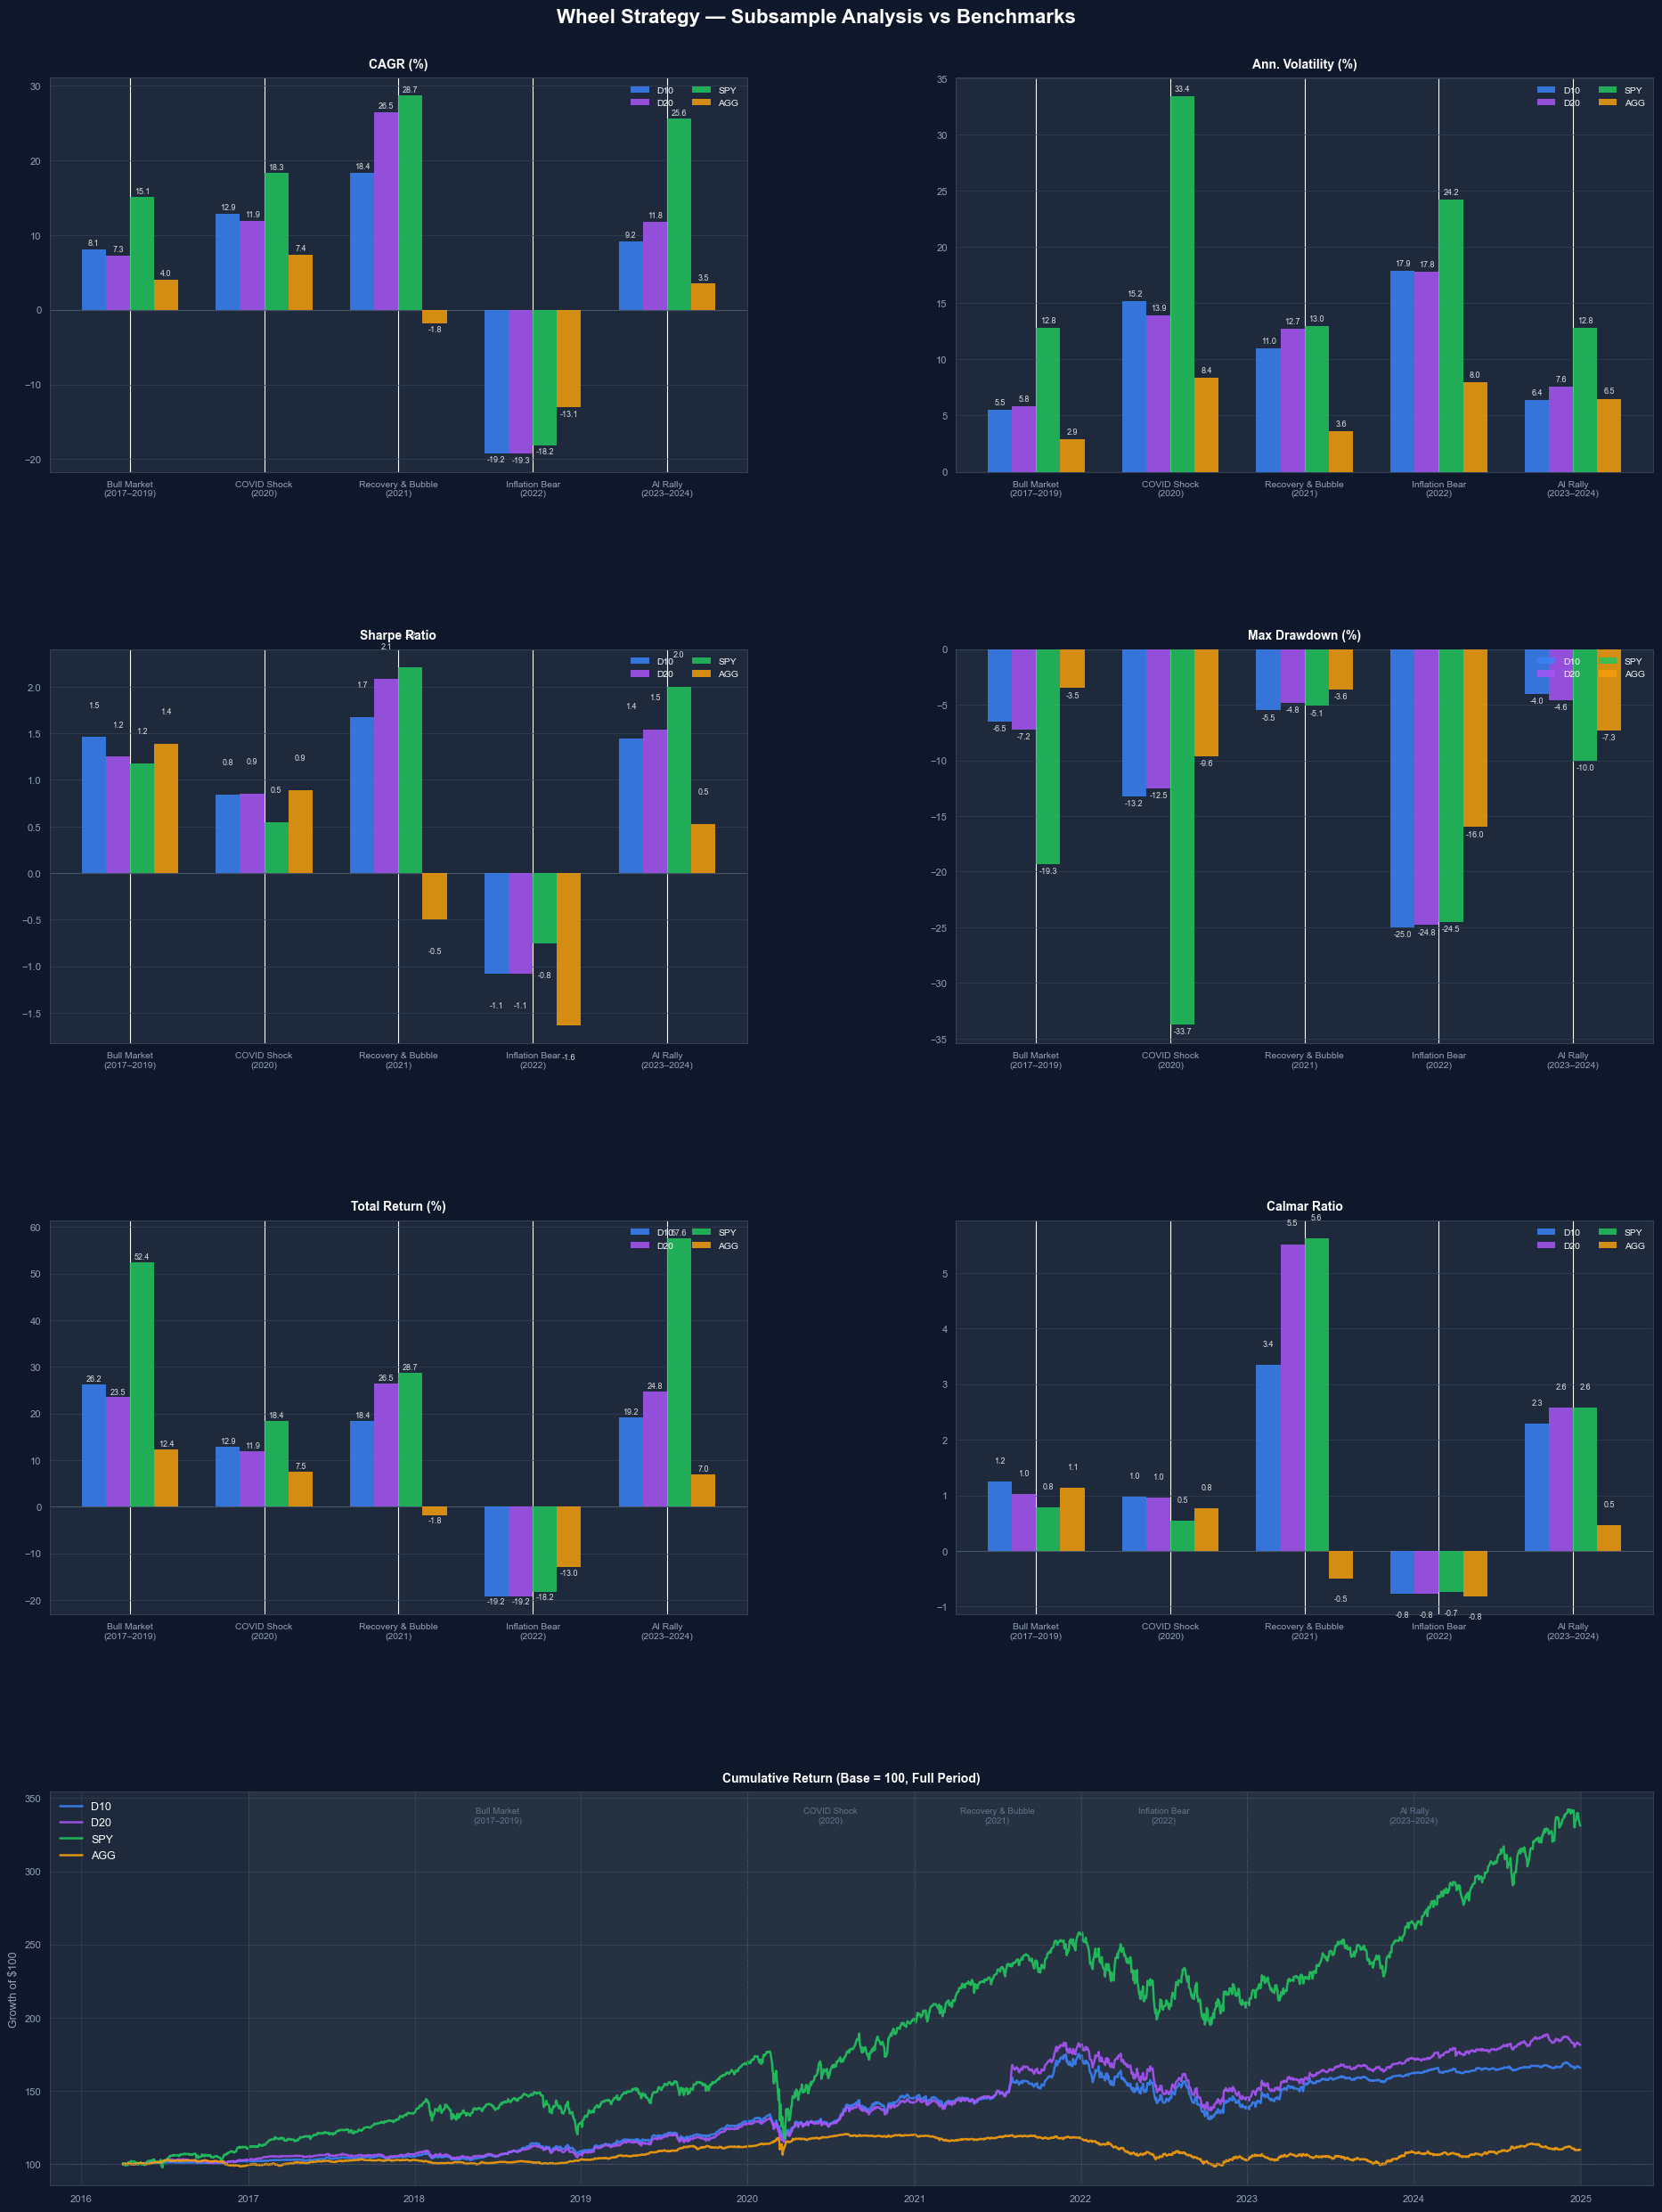

  Saved: subsample_metrics.csv

Done.


In [40]:
# ============================================================
# Subsample Performance Analysis
# Wheel Strategy (D10 / D20) vs SPY vs AGG
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import warnings
warnings.filterwarnings('ignore')
import wrds
db = wrds.Connection(wrds_username='harrisonl')

# ── 0. Configuration ─────────────────────────────────────────

SUBSAMPLES = {
    "Bull Market\n(2017–2019)":    ("2017-01-01", "2019-12-31"),
    "COVID Shock\n(2020)":         ("2020-01-01", "2020-12-31"),
    "Recovery & Bubble\n(2021)":   ("2021-01-01", "2021-12-31"),
    "Inflation Bear\n(2022)":      ("2022-01-01", "2022-12-31"),
    "AI Rally\n(2023–2024)":       ("2023-01-01", "2024-12-31"),
}

COLORS = {
    "D10": "#3b82f6",
    "D20": "#a855f7",
    "SPY": "#22c55e",
    "AGG": "#f59e0b",
}

# ── 1. Fetch SPY & AGG daily returns from WRDS ───────────────

print("Fetching SPY & AGG from WRDS...")

bench_query = """
    SELECT a.date, b.ticker, a.ret
    FROM crsp.dsf a
    JOIN crsp.dsenames b ON a.permno = b.permno
    WHERE b.ticker IN ('SPY', 'AGG')
      AND a.date >= '2016-04-01' AND a.date <= '2024-12-31'
      AND a.date >= b.namedt AND a.date <= b.nameendt
      AND a.ret IS NOT NULL
    ORDER BY b.ticker, a.date
"""
bench_raw = db.raw_sql(bench_query, date_cols=['date'])

# Drop duplicates — keep one row per (ticker, date)
bench_raw = bench_raw.sort_values(['ticker','date']).drop_duplicates(['ticker','date'])

# Pivot to wide format: rows = date, columns = ticker
bench = bench_raw.pivot(index='date', columns='ticker', values='ret')
bench.index = pd.to_datetime(bench.index)
print(f"  Benchmark rows: {len(bench)}, cols: {list(bench.columns)}")

# ── 2. Load Wheel strategy daily returns ─────────────────────

print("Loading Wheel daily portfolio...")

# Update path to match your actual output directory
dp = pd.read_csv('wheel_daily_portfolio.csv')
dp['date'] = pd.to_datetime(dp['date'])

wheel = {}
for sid in ['D10', 'D20']:
    sub = dp[dp['strategy_id'] == sid].sort_values('date').copy()
    sub['ret'] = sub['equity'].pct_change()
    sub = sub.set_index('date')[['ret']].rename(columns={'ret': sid})
    wheel[sid] = sub

# Merge all return series into a single wide DataFrame
all_rets = bench.copy()
for sid, df in wheel.items():
    all_rets = all_rets.join(df, how='outer')

all_rets = all_rets.sort_index().dropna(how='all')
print(f"  Combined table: {len(all_rets)} rows, {list(all_rets.columns)}")

# ── 3. Compute per-subsample performance metrics ─────────────

def calc_metrics(rets: pd.Series, freq=252) -> dict:
    """Given a daily return series, return a dict of annualised performance metrics."""
    rets = rets.dropna()
    if len(rets) < 5:
        return {k: np.nan for k in ['total_ret','cagr','vol','sharpe','mdd','calmar']}

    n_years = len(rets) / freq
    total_ret = (1 + rets).prod() - 1
    cagr = (1 + total_ret) ** (1 / n_years) - 1
    vol = rets.std() * np.sqrt(freq)
    sharpe = cagr / vol if vol > 0 else np.nan

    cum = (1 + rets).cumprod()
    roll_max = cum.cummax()
    dd = (cum - roll_max) / roll_max
    mdd = dd.min()
    calmar = cagr / abs(mdd) if mdd != 0 else np.nan

    return {
        'total_ret': round(total_ret * 100, 1),
        'cagr':      round(cagr * 100, 1),
        'vol':       round(vol * 100, 1),
        'sharpe':    round(sharpe, 3),
        'mdd':       round(mdd * 100, 1),
        'calmar':    round(calmar, 3),
    }

STRATEGIES = ['D10', 'D20', 'SPY', 'AGG']
METRIC_LABELS = {
    'total_ret': 'Total Return (%)',
    'cagr':      'CAGR (%)',
    'vol':       'Ann. Vol (%)',
    'sharpe':    'Sharpe',
    'mdd':       'Max DD (%)',
    'calmar':    'Calmar',
}

# Build nested results dict: results[period_label][strategy][metric]
results = {}
for period_label, (start, end) in SUBSAMPLES.items():
    mask = (all_rets.index >= start) & (all_rets.index <= end)
    seg = all_rets.loc[mask]
    results[period_label] = {}
    for s in STRATEGIES:
        if s in seg.columns:
            results[period_label][s] = calc_metrics(seg[s])
        else:
            results[period_label][s] = {k: np.nan for k in METRIC_LABELS}

# ── 4. Print summary tables to console ──────────────────────

# Full-period metrics (Apr 2016 – Dec 2024)
full_mask = (all_rets.index >= '2016-04-29') & (all_rets.index <= '2024-12-31')
full_seg  = all_rets.loc[full_mask]
full_results = {s: calc_metrics(full_seg[s]) for s in STRATEGIES if s in full_seg.columns}

print("\n" + "="*80)
print("FULL-PERIOD PERFORMANCE SUMMARY  (Apr 2016 – Dec 2024)")
print("="*80)
header = f"  {'Metric':<20}" + "".join(f"{s:>12}" for s in STRATEGIES)
print(header)
print("  " + "─"*76)
for metric, mlabel in METRIC_LABELS.items():
    row = f"  {mlabel:<20}"
    for s in STRATEGIES:
        val = full_results.get(s, {}).get(metric, np.nan)
        row += f"{str(val):>12}"
    print(row)

print("\n" + "="*80)
print("SUBSAMPLE PERFORMANCE SUMMARY")
print("="*80)

for period_label, strat_dict in results.items():
    clean_label = period_label.replace('\n', ' ')
    print(f"\n{'─'*60}")
    print(f"  {clean_label}")
    print(f"{'─'*60}")
    header = f"  {'Metric':<20}" + "".join(f"{s:>12}" for s in STRATEGIES)
    print(header)
    for metric, mlabel in METRIC_LABELS.items():
        row = f"  {mlabel:<20}"
        for s in STRATEGIES:
            val = strat_dict.get(s, {}).get(metric, np.nan)
            row += f"{str(val):>12}"
        print(row)

# ── 5. Visualisation: bar charts per metric ──────────────────

print("\nGenerating charts...")

periods = list(SUBSAMPLES.keys())
n_periods = len(periods)

fig = plt.figure(figsize=(20, 26), facecolor='#0f172a')
fig.suptitle('Wheel Strategy — Subsample Analysis vs Benchmarks',
             fontsize=16, fontweight='bold', color='white', y=0.98)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.45, wspace=0.3,
                       top=0.95, bottom=0.04, left=0.07, right=0.97)

ax_params = [
    (0, 0, 'cagr',    'CAGR (%)'),
    (0, 1, 'vol',     'Ann. Volatility (%)'),
    (1, 0, 'sharpe',  'Sharpe Ratio'),
    (1, 1, 'mdd',     'Max Drawdown (%)'),
    (2, 0, 'total_ret','Total Return (%)'),
    (2, 1, 'calmar',  'Calmar Ratio'),
]

short_periods = [p.replace('\n', '\n') for p in periods]
x = np.arange(n_periods)
bar_w = 0.18

for row, col, metric, title in ax_params:
    ax = fig.add_subplot(gs[row, col])
    ax.set_facecolor('#1e293b')
    ax.spines[:].set_color('#334155')
    ax.tick_params(colors='#94a3b8', labelsize=8)
    ax.yaxis.label.set_color('#94a3b8')

    for i, s in enumerate(STRATEGIES):
        vals = [results[p][s].get(metric, np.nan) for p in periods]
        offset = (i - 1.5) * bar_w
        bars = ax.bar(x + offset, vals, bar_w,
                      label=s, color=COLORS[s], alpha=0.85,
                      zorder=3, edgecolor='none')
        # Annotate bar values
        for bar, v in zip(bars, vals):
            if not np.isnan(v):
                va = 'bottom' if v >= 0 else 'top'
                yoff = 0.02 * ax.get_ylim()[1] if ax.get_ylim()[1] != 0 else 0.1
                ax.text(bar.get_x() + bar.get_width()/2,
                        bar.get_height() + (0.3 if v >= 0 else -0.3),
                        f'{v:.1f}', ha='center', va=va,
                        fontsize=6.5, color='white', alpha=0.85)

    ax.set_title(title, color='white', fontsize=10, fontweight='bold', pad=8)
    ax.set_xticks(x)
    ax.set_xticklabels([p.replace('\n', '\n') for p in periods], fontsize=7.5, color='#94a3b8')
    ax.axhline(0, color='#475569', linewidth=0.8, zorder=2)
    ax.grid(axis='y', color='#334155', linewidth=0.5, zorder=1)
    ax.legend(loc='upper right', fontsize=7.5, framealpha=0,
              labelcolor='white', ncol=2)

# ── Cumulative return line chart (full period, bottom panel) ──

ax_cum = fig.add_subplot(gs[3, :])
ax_cum.set_facecolor('#1e293b')
ax_cum.spines[:].set_color('#334155')
ax_cum.tick_params(colors='#94a3b8', labelsize=8)

for s in STRATEGIES:
    if s in all_rets.columns:
        cum = (1 + all_rets[s].fillna(0)).cumprod() * 100
        ax_cum.plot(cum.index, cum.values, label=s,
                    color=COLORS[s], linewidth=1.8, alpha=0.9)

# Shade each subsample region and add period labels
for period_label, (start, end) in SUBSAMPLES.items():
    ax_cum.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.04, color='white', zorder=1)
    ax_cum.axvline(pd.Timestamp(start), color='#334155',
                   linewidth=0.8, linestyle='--', zorder=2)
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax_cum.text(mid, ax_cum.get_ylim()[1] * 0.97 if ax_cum.get_ylim()[1] != 1 else 1.5,
                period_label.replace('\n', '\n'),
                ha='center', va='top', fontsize=7, color='#64748b')

ax_cum.set_title('Cumulative Return (Base = 100, Full Period)',
                 color='white', fontsize=10, fontweight='bold', pad=8)
ax_cum.axhline(100, color='#475569', linewidth=0.8, linestyle=':', zorder=2)
ax_cum.grid(color='#334155', linewidth=0.5, zorder=1)
ax_cum.legend(loc='upper left', fontsize=9, framealpha=0, labelcolor='white')
ax_cum.set_ylabel('Growth of $100', color='#94a3b8', fontsize=9)

plt.savefig('subsample_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0f172a')
print("  Saved: subsample_analysis.png")
plt.show()

# ── 6. Export metrics to CSV ─────────────────────────────────

rows = []
for period_label, strat_dict in results.items():
    clean = period_label.replace('\n', ' ')
    for s in STRATEGIES:
        m = strat_dict.get(s, {})
        rows.append({
            'Period': clean,
            'Strategy': s,
            **{METRIC_LABELS[k]: m.get(k, np.nan) for k in METRIC_LABELS}
        })

df_out = pd.DataFrame(rows)
df_out.to_csv('subsample_metrics.csv', index=False)
print("  Saved: subsample_metrics.csv")
print("\nDone.")

### FULL-PERIOD RESULTS
-------------------
Over the 8.7-year backtest, D10 and D20 delivered CAGRs of 6.0% and 7.1%
respectively (total returns: 65.9% / 81.5%), compared to SPY's 14.6% CAGR
(226% total) and AGG's 1.4% CAGR (12.4% total). The absolute return gap
versus SPY is a structural feature of premium-selling strategies: systematic
covered call writing caps upside participation during trending bull markets,
which dominated the 2016–2024 period.

On a risk-adjusted basis, the picture is more favourable. Both variants
achieved Sharpe ratios of 0.640 (D10) and 0.727 (D20) — significantly above
AGG (0.212) and approaching SPY (0.868) , while operating at annualised
volatility of approximately 10%, roughly 40% below SPY's 16.8%. Maximum
drawdown for both variants was approximately −25%, materially better than
SPY's −34.5% peak-to-trough decline during the 2020 COVID crash. Estimated
transaction costs ($0.25/contract commission + 1% execution slippage) reduced
total returns by 2.1% (D10) and 2.9% (D20) over the full period, equivalent
to less than 30bps annually, immaterial to the overall conclusions.

### SUBSAMPLE ANALYSIS
------------------
Performance varied substantially across market regimes:

  Bull Market (2017–2019): Both variants delivered Sharpe ratios above 1.25,
  outperforming SPY (1.18) on a risk-adjusted basis despite capturing only
  ~50% of SPY's absolute return. Annualised volatility of 5.5–5.8% versus
  SPY's 12.8% highlights the premium-compression effect in low-volatility
  environments, where realised vol consistently ran below implied vol,
  enriching option income.

  COVID Shock (2020): Maximum drawdowns of −12.5% to −13.2% compare
  favourably to SPY's −33.7%. Both variants outperformed SPY on all
  risk-adjusted metrics (Sharpe: 0.845–0.856 vs SPY's 0.548), demonstrating
  meaningful downside buffering during acute market dislocations. The
  elevated VIX during 2020 also enriched premium income, partially
  offsetting the equity losses from put assignments.

  Recovery & Bubble (2021): D20 posted 26.5% total return, within 2pp of
  SPY's 28.7%, while D10 returned 18.4%. The near-parity of D20 with SPY
  in a strong up-market demonstrates that the higher-delta variant can
  capture a meaningful share of equity upside in strongly trending regimes.

  Inflation Bear (2022): The most challenging period. Both variants lost
  approximately −19%, broadly in line with SPY (−18.2%), but at lower
  realised volatility (17.9% vs SPY's 24.2%). The strategy failed to
  provide the downside protection seen in 2020, as repeated put assignments
  during the drawdown accumulated long equity exposure at progressively
  lower prices, a structural vulnerability of short-volatility strategies
  in sustained bear markets.

  AI Rally (2023–2024): The strategy significantly underperformed SPY
  (D10: 9.2% CAGR vs SPY: 25.6%), though with strong risk-adjusted metrics
  (Sharpe: 1.45–1.54, max drawdown: −4.0% to −4.6%). The divergence
  reflects the equal-weight 20-stock universe's inability to capture gains
  concentrated in AI-adjacent mega-cap stocks. This period also recorded
  the lowest SPY correlation (0.57), consistent with narrow-breadth markets
  where diversified strategies decouple from index performance.

Analysis window : 2016-04-01 — 2024-12-31
Trading days    : 2,203

1. PAIRWISE CORRELATION MATRIX
       D10    D20    SPY    AGG
D10  1.000  0.925  0.774  0.145
D20  0.925  1.000  0.780  0.151
SPY  0.774  0.780  1.000  0.123
AGG  0.145  0.151  0.123  1.000

2. TAIL RISK METRICS  (daily returns, %)
          VaR_95  CVaR_95  VaR_99  CVaR_99  worst_day  skewness  exc_kurt
Strategy                                                                 
D10       -0.963   -1.569  -1.891   -2.645     -4.435    -0.273     7.628
D20       -0.960   -1.564  -1.869   -2.607     -3.789     0.370    13.215
SPY       -1.682   -2.765  -3.308   -4.717    -10.942    -0.595    13.731
AGG       -0.503   -0.803  -0.924   -1.401     -4.001    -1.093    19.476

Note: VaR/CVaR negative = loss. CVaR = Expected Shortfall.

Saved: correlation_tail_risk.png


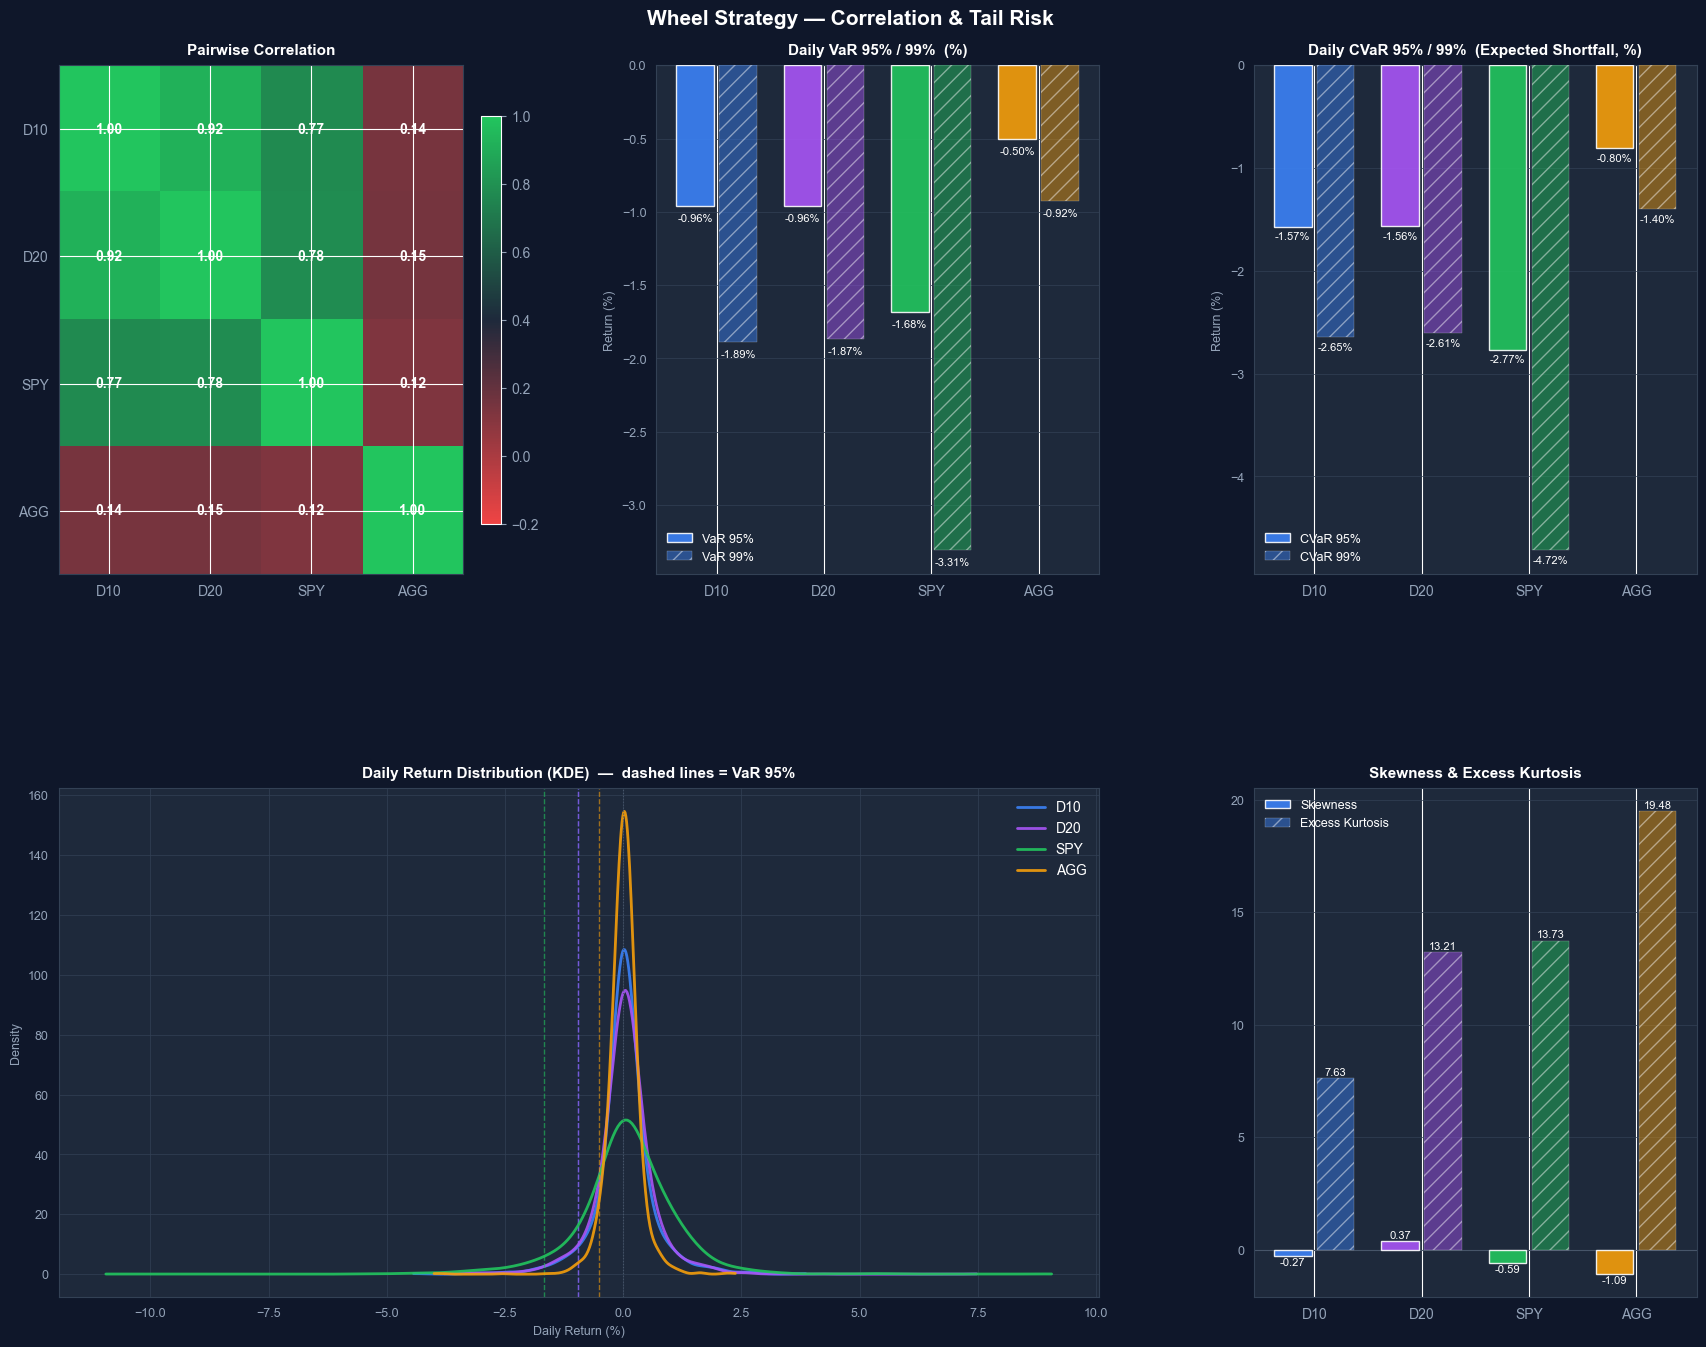

Saved: correlation_matrix.csv
Saved: tail_risk_metrics.csv

Done.


In [35]:
# ============================================================
# Correlation & Tail Risk Analysis
# Wheel Strategy (D10 / D20) vs SPY vs AGG
# Assumes `all_rets` is already in memory from subsample_analysis.py
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

COLORS     = {"D10": "#3b82f6", "D20": "#a855f7", "SPY": "#22c55e", "AGG": "#f59e0b"}
STRATEGIES = ['D10', 'D20', 'SPY', 'AGG']

rets = (all_rets[STRATEGIES]
        .apply(pd.to_numeric, errors='coerce')
        .dropna(how='all'))

print(f"Analysis window : {rets.index[0].date()} — {rets.index[-1].date()}")
print(f"Trading days    : {len(rets):,}\n")

# ── 1. Pairwise correlation matrix ───────────────────────────

corr = rets.corr()

print("=" * 50)
print("1. PAIRWISE CORRELATION MATRIX")
print("=" * 50)
print(corr.round(3).to_string())

# ── 2. Tail Risk — Historical VaR & CVaR ─────────────────────
# VaR(95%) : loss threshold exceeded on worst 5% of days
# VaR(99%) : loss threshold exceeded on worst 1% of days
# CVaR(95%): mean loss on days beyond VaR(95%)  [= Expected Shortfall]

CONFIDENCE_LEVELS = [0.95, 0.99]

tail_results = {}
for sid in STRATEGIES:
    r = rets[sid].dropna()
    row = {}
    for cl in CONFIDENCE_LEVELS:
        var  = r.quantile(1 - cl)       # negative number = loss
        cvar = r[r <= var].mean()        # mean of tail losses
        row[f'VaR_{int(cl*100)}']  = round(var  * 100, 3)
        row[f'CVaR_{int(cl*100)}'] = round(cvar * 100, 3)
    row['worst_day'] = round(r.min() * 100, 3)
    row['skewness']  = round(float(stats.skew(r)),     3)
    row['exc_kurt']  = round(float(stats.kurtosis(r)), 3)
    tail_results[sid] = row

tail_df = pd.DataFrame(tail_results).T
tail_df.index.name = 'Strategy'

print(f"\n{'=' * 50}")
print("2. TAIL RISK METRICS  (daily returns, %)")
print(f"{'=' * 50}")
print(tail_df.to_string())
print("\nNote: VaR/CVaR negative = loss. CVaR = Expected Shortfall.")

# ── 3. Visualisation ─────────────────────────────────────────

fig = plt.figure(figsize=(18, 14), facecolor='#0f172a')
fig.suptitle('Wheel Strategy — Correlation & Tail Risk',
             fontsize=15, fontweight='bold', color='white', y=0.98)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35,
                       top=0.94, bottom=0.06, left=0.06, right=0.97)

# ── Panel A: Correlation heatmap ─────────────────────────────
ax_corr = fig.add_subplot(gs[0, 0])
cmap = LinearSegmentedColormap.from_list('rg', ['#ef4444','#1e293b','#22c55e'], N=256)
im = ax_corr.imshow(corr.values, cmap=cmap, vmin=-0.2, vmax=1.0, aspect='auto')
ax_corr.set_xticks(range(4)); ax_corr.set_yticks(range(4))
ax_corr.set_xticklabels(STRATEGIES, color='#94a3b8', fontsize=10)
ax_corr.set_yticklabels(STRATEGIES, color='#94a3b8', fontsize=10)
ax_corr.set_facecolor('#1e293b')
ax_corr.spines[:].set_color('#334155')
ax_corr.set_title('Pairwise Correlation', color='white',
                  fontsize=11, fontweight='bold', pad=8)
for i in range(4):
    for j in range(4):
        ax_corr.text(j, i, f'{corr.values[i,j]:.2f}',
                     ha='center', va='center', fontsize=10,
                     color='white', fontweight='bold')
plt.colorbar(im, ax=ax_corr, fraction=0.046, pad=0.04).ax.tick_params(colors='#94a3b8')

# ── Panel B: VaR 95% / 99% ───────────────────────────────────
ax_var = fig.add_subplot(gs[0, 1])
ax_var.set_facecolor('#1e293b')
ax_var.spines[:].set_color('#334155')
ax_var.tick_params(colors='#94a3b8', labelsize=9)

x = np.arange(len(STRATEGIES))
var95 = [tail_results[s]['VaR_95'] for s in STRATEGIES]
var99 = [tail_results[s]['VaR_99'] for s in STRATEGIES]

bars1 = ax_var.bar(x - 0.2, var95, 0.35, label='VaR 95%',
                   color=[COLORS[s] for s in STRATEGIES], alpha=0.9, zorder=3)
bars2 = ax_var.bar(x + 0.2, var99, 0.35, label='VaR 99%',
                   color=[COLORS[s] for s in STRATEGIES], alpha=0.45,
                   hatch='//', edgecolor='white', linewidth=0.3, zorder=3)
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax_var.text(bar.get_x() + bar.get_width()/2, h - 0.05,
                    f'{h:.2f}%', ha='center', va='top', fontsize=8, color='white')

ax_var.set_xticks(x)
ax_var.set_xticklabels(STRATEGIES, color='#94a3b8', fontsize=10)
ax_var.set_title('Daily VaR 95% / 99%  (%)', color='white',
                 fontsize=11, fontweight='bold', pad=8)
ax_var.set_ylabel('Return (%)', color='#94a3b8', fontsize=9)
ax_var.axhline(0, color='#475569', linewidth=0.8)
ax_var.grid(axis='y', color='#334155', linewidth=0.5, zorder=1)
ax_var.legend(framealpha=0, labelcolor='white', fontsize=9)

# ── Panel C: CVaR (Expected Shortfall) ───────────────────────
ax_cvar = fig.add_subplot(gs[0, 2])
ax_cvar.set_facecolor('#1e293b')
ax_cvar.spines[:].set_color('#334155')
ax_cvar.tick_params(colors='#94a3b8', labelsize=9)

cvar95 = [tail_results[s]['CVaR_95'] for s in STRATEGIES]
cvar99 = [tail_results[s]['CVaR_99'] for s in STRATEGIES]

bars3 = ax_cvar.bar(x - 0.2, cvar95, 0.35, label='CVaR 95%',
                    color=[COLORS[s] for s in STRATEGIES], alpha=0.9, zorder=3)
bars4 = ax_cvar.bar(x + 0.2, cvar99, 0.35, label='CVaR 99%',
                    color=[COLORS[s] for s in STRATEGIES], alpha=0.45,
                    hatch='//', edgecolor='white', linewidth=0.3, zorder=3)
for bars in [bars3, bars4]:
    for bar in bars:
        h = bar.get_height()
        ax_cvar.text(bar.get_x() + bar.get_width()/2, h - 0.05,
                     f'{h:.2f}%', ha='center', va='top', fontsize=8, color='white')

ax_cvar.set_xticks(x)
ax_cvar.set_xticklabels(STRATEGIES, color='#94a3b8', fontsize=10)
ax_cvar.set_title('Daily CVaR 95% / 99%  (Expected Shortfall, %)',
                  color='white', fontsize=11, fontweight='bold', pad=8)
ax_cvar.set_ylabel('Return (%)', color='#94a3b8', fontsize=9)
ax_cvar.axhline(0, color='#475569', linewidth=0.8)
ax_cvar.grid(axis='y', color='#334155', linewidth=0.5, zorder=1)
ax_cvar.legend(framealpha=0, labelcolor='white', fontsize=9)

# ── Panel D: Return distribution KDE (wide) ──────────────────
ax_kde = fig.add_subplot(gs[1, :2])
ax_kde.set_facecolor('#1e293b')
ax_kde.spines[:].set_color('#334155')
ax_kde.tick_params(colors='#94a3b8', labelsize=9)

for sid in STRATEGIES:
    r     = rets[sid].dropna()
    kde_x = np.linspace(r.min(), r.max(), 400)
    kde   = stats.gaussian_kde(r, bw_method=0.3)
    ax_kde.plot(kde_x * 100, kde(kde_x), color=COLORS[sid],
                linewidth=2, label=sid, alpha=0.9)
    # Mark VaR 95% as dashed vertical line
    ax_kde.axvline(tail_results[sid]['VaR_95'], color=COLORS[sid],
                   linewidth=1, linestyle='--', alpha=0.6)

ax_kde.set_title('Daily Return Distribution (KDE)  —  dashed lines = VaR 95%',
                 color='white', fontsize=11, fontweight='bold', pad=8)
ax_kde.set_xlabel('Daily Return (%)', color='#94a3b8', fontsize=9)
ax_kde.set_ylabel('Density',          color='#94a3b8', fontsize=9)
ax_kde.axvline(0, color='#475569', linewidth=0.8, linestyle=':')
ax_kde.grid(color='#334155', linewidth=0.5, zorder=1)
ax_kde.legend(framealpha=0, labelcolor='white', fontsize=10)

# ── Panel E: Skewness & Excess Kurtosis ─────────────────────
ax_sk = fig.add_subplot(gs[1, 2])
ax_sk.set_facecolor('#1e293b')
ax_sk.spines[:].set_color('#334155')
ax_sk.tick_params(colors='#94a3b8', labelsize=9)

skew_vals = [tail_results[s]['skewness'] for s in STRATEGIES]
kurt_vals = [tail_results[s]['exc_kurt'] for s in STRATEGIES]

b1 = ax_sk.bar(x - 0.2, skew_vals, 0.35, label='Skewness',
               color=[COLORS[s] for s in STRATEGIES], alpha=0.9, zorder=3)
b2 = ax_sk.bar(x + 0.2, kurt_vals, 0.35, label='Excess Kurtosis',
               color=[COLORS[s] for s in STRATEGIES], alpha=0.45,
               hatch='//', edgecolor='white', linewidth=0.3, zorder=3)
for bars in [b1, b2]:
    for bar in bars:
        h = bar.get_height()
        va    = 'bottom' if h >= 0 else 'top'
        nudge = 0.05     if h >= 0 else -0.05
        ax_sk.text(bar.get_x() + bar.get_width()/2, h + nudge,
                   f'{h:.2f}', ha='center', va=va, fontsize=8, color='white')

ax_sk.set_xticks(x)
ax_sk.set_xticklabels(STRATEGIES, color='#94a3b8', fontsize=10)
ax_sk.set_title('Skewness & Excess Kurtosis', color='white',
                fontsize=11, fontweight='bold', pad=8)
ax_sk.axhline(0, color='#475569', linewidth=0.8)
ax_sk.grid(axis='y', color='#334155', linewidth=0.5, zorder=1)
ax_sk.legend(framealpha=0, labelcolor='white', fontsize=9)

plt.savefig('correlation_tail_risk.png', dpi=150,
            bbox_inches='tight', facecolor='#0f172a')
print("\nSaved: correlation_tail_risk.png")
plt.show()

# ── 4. Export ─────────────────────────────────────────────────

corr.round(3).to_csv('correlation_matrix.csv')
tail_df.to_csv('tail_risk_metrics.csv')
print("Saved: correlation_matrix.csv")
print("Saved: tail_risk_metrics.csv")
print("\nDone.")

### CORRELATION ANALYSIS
--------------------
The full-period D10/D20 vs SPY correlation of 0.774–0.780 is regime-
dependent and ranges from 0.57 (AI Rally, 2023–2024) to 0.91 (Inflation
Bear, 2022). The pattern of rising correlation during bear markets is a
characteristic short-volatility signature: put assignments mechanically
convert option exposure into long equity positions during drawdowns,
increasing delta and SPY co-movement precisely when diversification is
most valuable. The near-zero correlation with AGG (0.145–0.151) confirms
the strategy is not a fixed-income substitute. Inter-strategy correlation
between D10 and D20 is 0.925, with residual divergence driven by
differences in assignment frequency and resulting stock accumulation paths.

### TAIL RISK
---------
At the 95% confidence level, D10 and D20 have daily VaR of −0.96%, versus
SPY's −1.68%, approximately 75% larger in absolute terms. CVaR (Expected
Shortfall) at 99% is −2.65% / −2.61% for D10/D20 versus −4.72% for SPY,
indicating that in the worst 1% of trading days, Wheel Strategy losses are
on average 43% smaller than SPY's. The worst single day for D10 was −4.44%
versus SPY's −10.94%, a 2.5x difference driven by the income buffer of
systematic option premium. All strategies exhibit excess kurtosis (fat
tails): D10 at 7.63, D20 at 13.22, SPY at 13.73, and AGG at 19.48. The
high kurtosis of D20 relative to D10 reflects the higher-delta variant's
greater sensitivity to sharp market moves, particularly during assignment
waves. Return skewness is near-zero for both variants (D10: −0.27,
D20: +0.37), masking a regime-conditional pattern: mildly positive in
normal markets (frequent small premium income) and sharply negative during
stress periods (concentrated assignment losses).

### CONCLUSION
----------
The Wheel Strategy occupies a distinct position in the risk-return spectrum:
equity-like Sharpe ratios at substantially lower volatility and tail risk
than a passive equity allocation. Its core trade-off, truncated upside in
exchange for income and risk reduction, is well-suited to range-bound or
moderately trending markets but creates structural underperformance during
concentrated momentum rallies. The strategy's most significant risk is not
normal market volatility but sustained directional bear markets, where the
put-assignment mechanism creates involuntary long equity accumulation. A
higher-delta variant (D20) improves absolute return capture at the cost of
slightly higher drawdowns, while D10 prioritises risk reduction at the
expense of return. Both variants consistently outperform AGG on a total
return and risk-adjusted basis, positioning the strategy as a potential
equity risk premium harvester with bond-like volatility characteristics
rather than a fixed-income substitute.

### FUTURE WORK
-----------
Three extensions are identified as high-priority directions for improving
strategy performance and robustness:

  1. Volatility-Regime-Conditional Strike Selection
     The current implementation mechanically targets a fixed delta (D10 or
     D20) at every rebalance date, irrespective of the prevailing volatility
     environment. A more sophisticated approach would incorporate a
     realised-vs-implied volatility (RV/IV) signal to condition option
     writing. Specifically, options would only be sold when IV exceeds a
     trailing estimate of RV,  i.e., when the volatility risk premium (VRP)
     is positive and option premiums are rich relative to expected realised
     moves. In low-VRP or inverted environments (e.g., pre-earnings, acute
     stress), the strategy would reduce or suspend option writing, avoiding
     periods where premium income does not adequately compensate for the
     risk assumed. This extension would also allow dynamic delta targeting:
     selling higher-delta options when the VRP is wide (capturing more
     premium) and lower-delta options when the VRP is narrow (reducing
     exposure). Expected benefit: improved Sharpe ratio and reduced drawdown
     in volatility-spike regimes such as 2022.

  2. Equity-First Initialisation (Stock Enhancement Variant)
     The current strategy initialises with 100% cash and builds equity
     exposure only through put assignments. An alternative construction
     would begin with a fully-invested long equity portfolio (equal-weight
     across the selected universe) and immediately write covered calls
     against all positions,  effectively treating the Wheel as a systematic
     buy-write overlay rather than a cash-secured put strategy. This
     initialisation eliminates the ramp-up period during which the portfolio
     is underexposed to equity upside, and structurally captures more of the
     equity risk premium from day one. Under this design, covered call
     premiums serve as a return enhancer on an already-invested book, rather
     than as the primary income source on a cash-heavy portfolio. Based on
     the subsample results,  particularly 2021 (+28.7% for SPY) and
     2023-2024 (+57.6% for SPY),  the early-cycle underexposure of the
     current design is a significant drag; the equity-first variant would be
     expected to substantially narrow the CAGR gap versus SPY while
     preserving the volatility-compression benefit of systematic call writing.

  3. Idle Capital Deployment via Fractional Position Management
     Under the current position-sizing rule, each ticker is allocated 5% of
     portfolio capital and options are written in whole-contract (100-share)
     lots. When the allocated capital is insufficient to purchase exactly
     100 shares at the current stock price,  a common situation for
     higher-priced names, the residual cash sits idle and earns only the
     risk-free rate. Over a multi-year backtest with 20 positions, this
     idle capital effect compounds into a meaningful performance drag. A
     practical extension would deploy residual cash into put options on
     lower-priced stocks within the eligible universe (or a supplementary
     watchlist), effectively filling fractional allocations with additional
     premium income. An alternative approach is to use micro-lot or
     mini-option contracts where available. This extension is operationally
     straightforward and would improve capital efficiency without materially
     altering the strategy's risk profile, as the additional positions would
     remain subject to the same delta and universe selection filters.